# Семинар 4. Итерационные методы решения СЛАУ

Перед изучением материалов семинара рекомендуем посетить лекцию или посмотреть видеозапись лекции. Ссылки (YouTube): [лекция 3](https://m.youtube.com/watch?v=mMWOaiq-sC0&t=4255s) (начало темы), [лекция 4](https://m.youtube.com/watch?v=1MzfHvgqb78&t=22s) (продолжение), [лекция 5](https://m.youtube.com/watch?v=9yDoZU_WkuQ&t=2845s) (ещё одна тема, входящая в семинар).

Предполагается, что читатель знает
*   классификацию методов численного решения СЛАУ,
*   определения и примеры векторных и матричных норм, а также их свойства,
*   определение и свойства числа обусловленности,
*   определение матрицы, удовлетворяющей условию диагонального преобладания, и роль этого условия,
*   понятие вычислительной сложности численного метода,
*   основы линейной алгебры: матрицы и их свойства, собственные значения, знакоопределённые матрицы и т.п.

# Почему для решения реальных задач недостаточно прямых методов решения СЛАУ

На прошлом семинаре мы кратко рассмотрели прямые методы решения СЛАУ и выяснили, что с практической точки зрения интерес представляют только метод Гаусса и его модификации. Соответствующие алгоритмы просты, легко реализуемы и характеризуются приемлемой вычислительной сложностью.

Вспомним, однако, что основная цель, преследуемая при решении практических задач численными методами, состоит в **получении решения с заданной точностью за наиболее короткое время**. В этом контексте прямые методы решения СЛАУ обладают рядом недостатков.

Почти все прямые методы решения СЛАУ (за исключением метода сопряжённых градиентов) требуют **фиксированного количества операций** для нахождения решения. Это количество не зависит от наперёд заданной точности искомого ответа. При помощи прямых методов решение всегда находится с точностью до ошибок округления, даже если в рассматриваемой задаче такая точность не требуется.

Предположим для простоты, что вычисления проводятся в отсутствие ошибок округления. Если некоторый прямой метод требует выполнения $N$ арифметических операций, то найти точное решение (или хотя бы приближение к нему) за меньшее число операций будет невозможно. Нельзя, например, исключить половину операций и выполнить только $N/2$ действий: прямой метод в этом случае не даст никакого осмысленного ответа, т.к. будут найдены не все компоненты решения. Другими словами, **при использовании прямых методов нельзя выиграть во времени выполнения вычислений за счёт приемлемого (в условиях задачи) проигрыша в точности получаемого решения**, поскольку прямые методы либо дают точный ответ (с поправкой на ошибки округления), либо не дают никакого ответа. Напротив, итерационные методы, о которых пойдёт речь ниже, позволяют регулировать количество выполняемых операций путём изменения требований к точности (приближённого) решения.

Кроме того, все прямые методы требуют знания элементов матрицы СЛАУ в явном виде. Однако встречаются случаи, когда решаемая СЛАУ задаётся не в векторно-матричной, а в операторной форме. Для решения такой СЛАУ прямыми методами необходимо предварительно получить её матрицу. Для итерационных же методов **хранение матрицы не нужно**: итерационный процесс можно строить путём последовательного действия заданным оператором на приближения к решению.

Исключительная важность итерационных методов определяется также тем, что во многих случаях решение СЛАУ большой размерности прямыми методами занимает неприемлемо длительное время. С другой стороны, итерационные методы в тех же случаях позволяют найти приближённое решение за разумное время. Этот фактор — **фактор времени вычислений** — очень часто оказывается решающим. Далее мы покажем, что **в случае СЛАУ большой размерности расчёт по итерационным методам может требовать меньшего числа операций (а значит, меньшего времени), чем расчёт по прямым методам**.

Ещё на первом семинаре мы дали характерный пример физической задачи, численное решение которой приводит к СЛАУ с большим количеством неизвестных. Речь идёт о краевой задаче для уравнений Лапласа или Пуассона в кубе. Если ввести сетку из 100 точек по каждой координате ($x$, $y$ и $z$), то после аппроксимации дифференциальной задачи получится СЛАУ, включающая $10^6$ уравнений. Решение такой СЛАУ по методу Гаусса потребует порядка $10^{18}$ операций. В следующем семестре мы будем изучать специальные методы, позволяющие решать подобные СЛАУ за существенно меньшее число операций (например, порядка $10^9$; корректная оценка зависит, разумеется, от требуемой точности решения). Целью же этого семинара является знакомство с основными принципами построения и использования итерационных методов на конкретном примере.

Итерационных методов решения СЛАУ существует очень много. Мы рассмотрим четыре простейших метода:
* метод простых итераций (МПИ),
* метод Якоби,
* метод Зейделя,
* метод последовательной верхней релаксации (ПВР).

Рассмотрение первого метода будет в большей степени методическим, так как метод является медленным и не используется в реальных задачах. Однако на примере метода простых итераций удобно демонстрировать основные закономерности.

Следующие два метода (Якоби и Зейделя) тоже медленные, но знакомство с ними необходимо для понимания последнего из перечисленных методов (ПВР). Метод последовательной верхней релаксации относится уже к методам средней скорости сходимости и используется на практике. Существуют и ещё более быстрые методы. Некоторые из них мы рассмотрим в весеннем семестре в контексте численного решения уравнений эллиптического типа на примере уравнения Пуассона (классификацию уравнений в частных производных изучают в курсе математической физики).

**Замечание.** Их сказанного выше вовсе не следует, что при решении СЛАУ надо однозначно отдавать предпочтение итерационным методам. Вообще говоря, **вычислительная математика — это наука не о том, как создать один суперметод, пригодный для всех задач данного класса, а о том, как для данной задачи подобрать наиболее подходящий метод численного решения из множества имеющихся**. Отметим, что часто для реальных задач приходится создавать специальные численные методы, наиболее полно учитывающие ключевые особенности этих задач. С задачей создания новых методов столкнётся, конечно, не каждый слушатель курса. Однако уже для осознанного выбора метода решения даже какой-то не слишком сложной и вполне типичной задачи принципиально важно иметь чёткое представление о наличии двух классов методов (прямых и итерационных) и их особенностях. Для этого мы и остановились на вопросе о роли итерационных методов сравнительно подробно.

# Метод простых итераций

Рассмотрим СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ с невырожденной матрицей $\textbf{A}$ и нетривиальной правой частью $\textbf{f}$. Проведём несколько равносильных преобразований:

$$\textbf{A}\textbf{x}=\textbf{f}\quad\Leftrightarrow\quad \textbf{x}+\tau\textbf{A}\textbf{x}=\tau\textbf{f}+\textbf{x} \quad\Leftrightarrow\quad \textbf{x}=\textbf{R}\textbf{x}+\textbf{F},\quad \textbf{R}\equiv\textbf{E}-\tau\textbf{A}, \quad \textbf{F}=\tau\textbf{f}.$$

Здесь $\tau$ — положительное вещественное число, называемое **итерационным параметром**, $\textbf{R}$ — **матрица** (оператор) **перехода**.

Составим последовательность векторов $\textbf{x}^{(s)}$, определив её рекуррентным соотношением, следующим из последнего уравнения:

$$\textbf{x}^{(s+1)}=\textbf{R}\textbf{x}^{(s)}+\textbf{F},\quad s=0,\,1,\,...\, .$$

Начальный вектор последовательности ("нулевое приближение") $\textbf{x}^{(0)}$ выберем произвольным образом.

**Метод простых итераций** (далее — МПИ) численного решения СЛАУ заключается в поиске приближения к точному решению $\textbf{x}=\textbf{u}$ исходной СЛАУ в виде $s$-ого вектора составленной последовательности. Иначе говоря, полагают, что $\textbf{u}\simeq \textbf{x}^{(s)}$, если $s$ достаточно велико. Из сути метода ясно, что найти (приближённое) решение СЛАУ с его помощью можно только при условии **сходимости** последовательности $\textbf{x}^{(s)}$ **к точному решению**:

$$\lim_{s\to\infty}\textbf{x}^{(s)}\to\textbf{u}.$$

Если сходимость отсутствует, то рассчитывать на близость $s$-го приближения к точному решению нельзя.

Поскольку равенство $\textbf{x}=\textbf{R}\textbf{x}+\textbf{F}$ равносильно исходной СЛАУ, оно удовлетворяется на точном решении $\textbf{x}=\textbf{u}$. Иначе говоря, имеем тождество

$$\textbf{u}=\textbf{R}\textbf{u}+\textbf{F}.$$

Вычитая из него равенство

$$\textbf{x}^{(s+1)}=\textbf{R}\textbf{x}^{(s)}+\textbf{F}$$

и вводя обозначение для погрешности на $s$-й итерации $\boldsymbol{\Delta}^{(s)}=\textbf{u}-\textbf{x}^{(s)}$, получаем закон изменения погрешности:

$$\boldsymbol{\Delta}^{(s+1)}=\textbf{R}\boldsymbol{\Delta}^{(s)}.$$

В качестве меры величины погрешности выберем, как и ранее, её норму. Имеем равенство:

$$||\boldsymbol{\Delta}^{(s+1)}||=||\textbf{R}\boldsymbol{\Delta}^{(s)}||.$$

Применим ($s+1$ раз) неравенство для согласованных норм вектора и матрицы:

$$\begin{align}
||\boldsymbol{\Delta}^{(s+1)}||&=||\textbf{R}\boldsymbol{\Delta}^{(s)}||\leq ||\textbf{R}||\cdot ||\boldsymbol{\Delta}^{(s-1)}||=\\
&=||\textbf{R}||\cdot ||\textbf{R}\boldsymbol{\Delta}^{(s-2)}||\leq ||\textbf{R}||^2\cdot ||\boldsymbol{\Delta}^{(s-2)}||\leq\,...\,\leq||\textbf{R}||^{s+1}\cdot||\boldsymbol{\Delta}^{(0)}||.
\end{align}$$

Величина $q\equiv ||\textbf{R}||>0$ называется **скоростью сходимости итерационного процесса**. Таким образом,

$$||\boldsymbol{\Delta}^{(s)}||\leq q^{s}||\boldsymbol{\Delta}^{(0)}||.$$

Если $q<1$, то $\displaystyle\lim_{s\to\infty}q^s=0$, так что $||\boldsymbol{\Delta}^{(s)}||\to 0$ при $s\to\infty$, т.е. выполнено условие сходимости итераций. Сформулируем этот результат в виде теоремы.

**Теорема 1 (достаточное условие сходимости МПИ).** Пусть в пространстве $\mathbb{R}^n$ выбрана некоторая векторная норма. Если согласованная с ней матричная норма такова, что

$$||\textbf{R}||=q<1,$$

где $\textbf{R}=\textbf{E}-\tau\textbf{A}$, то метод простых итераций

$$\textbf{x}^{(s+1)}=\textbf{R}\textbf{x}^{(s)}+\tau\textbf{f},$$

используемый для (приближённого) решения невырожденной СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$, сходится к точному решению $\textbf{x}=\textbf{u}$ не медленнее геометрической прогрессии со знаменателем $q$, причём сходимость имеет место при произвольном начальном приближении $\textbf{x}^{(0)}$.

Подчеркнём, что в силу теоремы об эквивалентности норм для сходимости итерационного процесса достаточно выполнения условия $||\textbf{R}||=q<1$ в **какой-либо одной** матричной норме. На практике наиболее просто проверить это условие, применив первую или вторую нормы. При отрицательном результате необходимо сделать проверку в третьей норме, так как для данной матрицы она минимальна. Напомним, что для вычисления третьей матричной нормы (подчинённой евклидовой векторной норме) необходимо найти максимальное по модулю собственное значение матрицы. Об этой задаче речь пойдёт ниже.

Отметим также, что **сходимость МПИ будет тем быстрее, чем ближе величина** $q$ **к нулю**. В этом смысле установившаяся терминология не вполне удачна (получается, что чем больше скорость $q$, тем медленнее сходится МПИ, хотя, например, в физике увеличение скорости процесса обычно влечёт уменьшение времени, занимаемого процессом).

Несколько сложнее предыдущего доказывается более сильный результат — критерий сходимости МПИ.

**Теорема 2 (необходимое и достаточное условие сходимости МПИ).** Метод простых итераций

$$\textbf{x}^{(s+1)}=\textbf{R}\textbf{x}^{(s)}+\textbf{F}$$

сходится (в произвольной норме) при любом начальном приближении $\textbf{x}^{(0)}$ в том и только в том случае, если модуль каждого собственного значения оператора перехода $\textbf{R}$ *строго меньше* единицы:

$$|\lambda_i(\textbf{R})|<1,\quad i=1,\,2,\, ...,\, n.$$

Обратим внимание на то, что в условии теоремы 2 СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ вообще не упоминается, поскольку очевидно, что если МПИ сходится, то предел последовательности $\textbf{x}^{(s)}$ является решением СЛАУ $\textbf{x}=\textbf{R}\textbf{x}+\textbf{F}$ (и любой эквивалентной СЛАУ).

Итак, сходимость МПИ напрямую связана со свойствами оператора перехода $\textbf{R}=\textbf{E}-\tau\textbf{A}$, т.е. зависит от величины итерационного параметра $\tau$. В связи с этим естественно поставить три следующих вопроса:

*   Как выбрать $\tau$, чтобы МПИ сходился?
*   Как выбрать $\tau$, чтобы сходимость МПИ была самой быстрой из возможных?
*   Какое количество итераций необходимо выполнить (при фиксированном $\tau$) для достижения заданной точности приближённого решения?



Начнём с последнего вопроса. Из неравенства

$$||\boldsymbol{\Delta}^{(s)}||\leq q^{s}||\boldsymbol{\Delta}^{(0)}||.$$

логарифмированием получаем:

$$s\geq \ln\frac{||\boldsymbol{\Delta}^{(s)}||}{||\boldsymbol{\Delta}^{(0)}||}\cdot(\ln{q})^{-1}.$$

Пусть за $s$ итераций требуется найти решение с точностью $\varepsilon$. Это значит, что должно выполняться неравенство $||\boldsymbol{\Delta}^{(s)}||\leq\varepsilon$. Учитывая, что $||\boldsymbol{\Delta}^{(s)}||$ убывает с увеличением $s$, получаем:

$$s\geq \ln\frac{\varepsilon}{||\boldsymbol{\Delta}^{(0)}||}\cdot(\ln{q})^{-1}.$$

Погрешность начального приближения $\boldsymbol{\Delta}^{(0)}$ (как и любую другую погрешность) на практике **нельзя вычислить**, поскольку неизвестно точное решение СЛАУ. Поэтому критерий остановки итераций формулируют иначе — рассматривают другую величину, легко вычисляемую по известному приближению к решению. Такой величиной служит невязка. Введём соответствующее понятие.

Перепишем решаемую СЛАУ в виде $\textbf{f}-\textbf{A}\textbf{x}=\textbf{0}$. Будем рассматривать левую часть этого равенства как функцию $\textbf{x}$:

$$\textbf{r}(\textbf{x})=\textbf{f}-\textbf{A}\textbf{x}.$$

Понятно, что на точном решении эта функция, как и погрешность $\boldsymbol{\Delta}(\textbf{x})$, обращается в нуль: $\textbf{r}(\textbf{u})=\textbf{0}$. Её значение при $\textbf{x}=\textbf{x}^{(s)}$ и называется **невязкой на $s$-й итерации**:

$$\textbf{r}^{(s)}\equiv \textbf{r}\big(\textbf{x}^{(s)}\big)=\textbf{f}-\textbf{A}\textbf{x}^{(s)}.$$

Легко видеть, что невязка характеризует отличие левой и правой частей исходной СЛАУ при подстановке в неё приближённого решения (вместо точного).

Можно показать, что при переходе к следующему приближению **невязка меняется по тому же закону, что и погрешность**:

$$\textbf{r}^{(s+1)}=\textbf{R}\textbf{r}^{(s)}.$$

В самом деле, выделим невязку $\textbf{r}^{(s)}$ в векторно-матричной записи МПИ:

$$\textbf{x}^{(s+1)}=(\textbf{E}-\tau\textbf{A})\textbf{x}^{(s)}+\tau\textbf{f}=\textbf{x}^{(s)}+\tau\textbf{r}^{(s)}.$$

Домножим обе части равенства на $-\textbf{A}$, прибавим к обеим частям $\textbf{f}$ и снова применим определение невязки:

$$\textbf{r}^{(s+1)}=\textbf{r}^{(s)}-\tau\textbf{A}\textbf{r}^{(s)}=(\textbf{E}-\tau\textbf{A})\textbf{r}^{(s)}=\textbf{R}\textbf{r}^{(s)},$$

что и требовалось. Заметим, что попутно мы вывели формулу

$$\textbf{x}^{(s+1)}-\textbf{x}^{(s)}=\tau\textbf{r}^{(s)}.$$

Она понадобится нам при программной реализации МПИ.

Вернёмся к оценке числа итераций. Так как законы изменения погрешности и невязки одинаковы, можно написать (в предыдущем неравенстве для $s$ погрешность $\boldsymbol{\Delta}^{(0)}$ формально заменяется на $\textbf{r}^{(0)}$):

$$s\geq \ln\frac{\varepsilon}{||\textbf{r}^{(0)}||}\cdot(\ln{q})^{-1},\quad q=||\textbf{R}||.$$

Вообще говоря, число итераций МПИ можно оценивать по-разному (на основании разных условий). Два условия: $||\boldsymbol{\Delta}^{(s)}||\leq \varepsilon$ и $||\textbf{r}^{(s)}||\leq \varepsilon$ — уже упоминались (первое из них принципиально непроверяемо, а для второго мы установили искомую оценку). Есть и третья возможность: можно потребовать, чтобы погрешность за $s$ итераций уменьшилась в $1/\varepsilon$ раз. Тогда

$$s\geq \ln \varepsilon \cdot(\ln{q})^{-1},\quad q=||\textbf{R}||.$$




Что касается первых двух из сформулированных выше вопросов, то на них можно дать теоретически обоснованный ответ в случае **симметричной и положительно определённой** матрицы СЛАУ (иногда СЛАУ с такими матрицами называют **нормальными**). Именно, справедлива следующая теорема.

**Теорема 3.** Пусть матрица СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ симметрична и положительно определена, а $\lambda_\text{min}$ и $\lambda_\text{min}$ — её наименьшее и наибольшее собственные значения соответственно. Тогда при

$$0<\tau<\frac{2}{\lambda_\text{max}}$$

метод простых итераций сходится к точному решению СЛАУ вне зависимости от начального приближения $\textbf{x}^{(0)}$, причём скорость сходимости есть

$$q(\tau)=\max\big(|1-\tau\lambda_\text{min}|,|1-\tau\lambda_\text{max}|\big)<1.$$

**Упражнение.** Выведите условие $\tau<2/\lambda_\text{max}$. *Указание:* обратитесь к одной из сформулированных выше теорем.

Поскольку МПИ сходится тем быстрее, чем меньше (ближе к нулю) $q$, для нахождения оптимального параметра $\tau_\text{opt}$, отвечающего наискорейшей сходимости, надо минимизировать функцию $q(\tau)$. Интуитивно понятно, что минимум достигается при равенстве аргументов максимума, входящего в выражение $q(\tau)$. Это можно доказать и строго. Таким образом, МПИ сходится наиболее быстро при

$$\tau_\text{opt}=\frac{2}{\lambda_\text{min}+\lambda_\text{max}},$$

а соответствующая скорость сходимости есть

$$q_\text{opt}=q(\tau_\text{opt})=\frac{\lambda_\text{max}-\lambda_\text{min}}{\lambda_\text{max}+\lambda_\text{min}}=\frac{\mu(\textbf{A})-1}{\mu(\textbf{A})+1}.$$

Как видим, **чем лучше обусловлена СЛАУ, тем быстрее сходится МПИ с оптимальным итерационным параметром**. Если же СЛАУ плохо обусловлена, то скорость сходимости $q_\text{opt}$ лишь немного меньше единицы, т.е. сходимость получается медленной. Например, при $\mu(\textbf{A})=2$ скорость сходимости $q_\text{opt}=1/3$. А при  $\mu(\textbf{A})=99999 \approx 10^5$ скорость сходимости $q_\text{opt}=0,99998$.

Если матрица СЛАУ не является симметричной и положительно определённой (как предполагается в теореме 3), то можно перейти к эквивалентной системе путём **симметризации Гаусса**. Симметризация заключается в домножении обеих частей СЛАУ на $\textbf{A}^\text{T}$:

$$\textbf{A}^\text{T}\textbf{A}\textbf{x}=\textbf{A}^\text{T}\textbf{f}.$$

Получается эквивалентная СЛАУ $\textbf{B}\textbf{x}=\textbf{b}$ с симметричной положительно определённой матрицей $\textbf{B}=\textbf{A}^\text{T}\textbf{A}$ и правой частью $\textbf{b}=\textbf{A}^\text{T}\textbf{f}$. К этой СЛАУ уже можно применять результаты теоремы 3. Правда, **новая СЛАУ будет обусловлена хуже исходной**, поскольку $\mu(\textbf{B})=\mu^2(\textbf{A})$, а значит, МПИ для этой СЛАУ будет сходиться медленнее, чем для СЛАУ с матрицей $\textbf{A}$. Так, в примере выше после симметризации $\mu^2(\textbf{A})=4$ и $q_\text{opt}=3/5>1/3$ в первом случае. Во втором случае $\mu^2(\textbf{A})\approx 10^{10}$ и $q_\text{opt}=0,9999999998$.

Проблему роста числа обусловленности при симметризации Гаусса можно отчасти решить путём предварительного **масштабирования СЛАУ**.

Суть масштабирования состоит в том, что каждое уравнение исходной СЛАУ умножается на
такой множитель, чтобы наибольший коэффициент преобразованного уравнения
оказался равным единице. После масштабирования осуществляется симметризация Гаусса. При таком подходе симметризованная система будет лучше обусловлена.

**Примечания:**

1.  Выше мы отдельно рассмотрели случай СЛАУ с **симметричной положительно определённой матрицей**. С этим классом матриц мы будем работать и в дальнейшем. Отметим, что в некоторых источниках в определение положительной определённости (и вообще знакоопределённости) матрицы включается требование симметричности. Мы же будем разграничивать эти два понятия и считать матрицу $\textbf{A}$ положительно определённой, если $\textbf{x}^\text{T}\textbf{A}\textbf{x}>0$ для всякого ненулевого вектора $\textbf{x}$. При этом матрица $\textbf{A}$ может и не быть симметричной, в чём легко убедиться с помощью примера:

    $$\textbf{A}=
      \begin{pmatrix}
        1 & 1 \\
        -1 & 1
      \end{pmatrix}.$$
      
    Эта матрица положительно определена, хотя и несимметрична.

2.  Как уже отмечалось, СЛАУ с симметричными положительно определёнными матрицами иногда называют нормальными. Не следует путать понятие нормальной СЛАУ с понятием **нормальной матрицы**. Матрица $\textbf{A}$ называется нормальной, если она коммутирует со своей транспонированной: $\textbf{A}\textbf{A}^\text{T}=\textbf{A}^\text{T}\textbf{A}$. В комплексном случае соответствующее условие имеет вид $\textbf{A}\textbf{A}^\dagger=\textbf{A}^\dagger\textbf{A}$.

# Задача 1

Для СЛАУ $\textbf{A}\textbf{x}=\textbf{f}$ с матрицей

$$
  \textbf{A}=
    \begin{pmatrix}
      -2 & 1 \\
       0 & 2
    \end{pmatrix}
$$

и правой частью

$$
  \textbf{f}=
    \begin{pmatrix}
      3 \\
      1
    \end{pmatrix}
$$

построить сходящийся МПИ, т.е. указать область значений итерационного параметра $\tau$, в которой имеет место сходимость. Найти оптимальное значение итерационного параметра $\tau_\text{opt}$ и соответствующую скорость сходимости $q_\text{opt}$. Оценить по невязке число итераций $s$, необходимое для достижения точности $\varepsilon=10^{-3}$, если в качестве начального приближения выбран нулевой вектор.

**Решение.** Матрица системы не является симметричной и, кроме того, не является положительной определённой. В последнем легко убедиться с помощью критерия Сильвестра или по собственным значениям — они легко угадываются: $\lambda(\textbf{A})=\pm 2$. Поэтому выполним симметризацию Гаусса:

$$\textbf{B}=\textbf{A}^\text{T}\textbf{A}=
  \begin{pmatrix}
    -2 & 0\\
    1 & 2
  \end{pmatrix}
  \begin{pmatrix}
    -2 & 1\\
    0 & 2
  \end{pmatrix}=
  \begin{pmatrix}
    4 & -2\\
    -2 & 5
  \end{pmatrix};$$

$$\textbf{b}=\textbf{A}^\text{T}\textbf{f}=
  \begin{pmatrix}
    -2 & 0\\
    1 & 2
  \end{pmatrix}
  \begin{pmatrix}
    3 \\
    1
  \end{pmatrix}=
  \begin{pmatrix}
    -6 \\
    5
  \end{pmatrix}.$$

Собственные значения матрицы $\textbf{B}$ находим стандартным способом:

$$(4-\lambda)(5-\lambda)-4=0\quad\Rightarrow\quad\lambda(\textbf{B})=\frac{9\pm\sqrt{17}}{2}.$$

По этим значениям определяем область сходимости МПИ, а также оптимальные значения итерационного параметра и скорости сходимости:

$$0<\tau<\frac{2}{\lambda_\text{max}}=\frac{4}{9\pm\sqrt{17}},\quad\tau_\text{opt}=\frac{2}{\lambda_\text{min}+\lambda_\text{max}}=\frac{2}{9},\quad q_\text{opt}=\frac{\lambda_\text{max}-\lambda_\text{min}}{\lambda_\text{max}+\lambda_\text{min}}=\frac{\sqrt{17}}{9}\simeq 0,458.$$

Можно выписать и рекуррентную формулу для последовательности $\textbf{x}^{(s)}$ при $\tau=\tau_\text{opt}$:

$$\textbf{R}=\textbf{E}-\tau_\text{opt}\textbf{B}=\frac{1}{9}
  \begin{pmatrix}
    1 & 4\\
    4 & -1
  \end{pmatrix};\quad \textbf{F}=\tau_\text{opt}\textbf{b}=\begin{pmatrix}
    -4/3\\
    10/9
  \end{pmatrix};$$

$$\textbf{x}^{(s+1)}=\frac{1}{9}\begin{pmatrix}
    1 & 4\\
    4 & -1
  \end{pmatrix}\textbf{x}^{(s)}+\begin{pmatrix}
    -4/3\\
    10/9
  \end{pmatrix}.$$

Число итераций оцениваем по формуле

$$s\geq s_\text{min}=\ln\frac{\varepsilon}{||\textbf{r}^{(0)}||_3}\cdot(\ln{q})^{-1},\quad q=||\textbf{R}||_\text{III}.$$

Поскольку $\textbf{x}^{(0)}=\textbf{0}$, невязка на нулевой итерации есть $\textbf{r}^{(0)}=\textbf{b}$. Далее, $||\textbf{r}^{(0)}||_3=||\textbf{b}||=\sqrt{61}$. Наконец, $||\textbf{R}||_\text{III}=\sqrt{17}/9=q_\text{opt}$. Окончательно имеем:

$$s_\text{min}=\ln\frac{10^{-3}}{\sqrt{61}}\cdot\bigg(\ln\frac{\sqrt{17}}{9}\bigg)^{-1}\simeq 11,482.$$

Округляя до ближайшего целого **в большую сторону**, получаем: $s\geq 12$. Можно было бы при подсчёте $s_\text{min}$ воспользоваться другими векторными и матричными нормами. В случае использования первой или второй нормы оценка дала бы $s\geq 15$.

# Программная реализация МПИ

Среди математических библиотек Python нет такой, которая предлагала бы готовую реализацию МПИ. Однако его легко реализовать и самостоятельно. Напишем функцию, решающую заданную СЛАУ при помощи МПИ с оптимальным итерационным параметром. Помимо матрицы СЛАУ и её правой части, она будет принимать на вход требуемую точность решения. Предусмотрим автоматическую симметризацию матрицы (при необходимости).

"Вычислительное ядро" функции, т.е. ту её часть, которая ответственна за сам расчёт последовательных приближений, можно реализовать разными способами. Как правило, **при написании кода на Python стараются избегать явных циклов**, прибегая к векторизации вычислений с помощью средств библиотеки ```numpy```. Однако устранить циклы удаётся не всегда. От них затруднительно избавиться в тех случаях, когда вычисления носят рекуррентный характер. С подобным примером мы уже сталкивались на прошлом семинаре, когда проверяли правильность решения разностного уравнения при вычислении сложности метода Крамера.

Как мы увидим ниже, при реализации МПИ уйти от циклов всё же возможно. Но в простейшем варианте "вычислительного ядра" можно использовать и цикл — либо с проверкой условия (цикл ```while```), либо с фиксированным количеством итераций (цикл ```for```):

In [ ]:
import numpy as np

def SI_kernel_loop1(R: np.ndarray, F: np.ndarray, eps: float):
    u = np.zeros(2) # в качестве начального приближения выбираем нулевой вектор
    # для примера рассматриваем случай n=2

    statement = True
    while statement:
        v = R @ u + F
        statement = np.linalg.norm(v-u, ord=2) > eps
        u = v

    return u

def SI_kernel_loop2(R: np.ndarray, F: np.ndarray, s: int):
    u = np.zeros(2)

    for i in range(1, s):
        v = R @ u + F
        u = v

    return u

В предыдущем разделе упоминалось, что невозможно напрямую вычислить погрешность $\boldsymbol{\Delta}^{(s)}$ приближённого решения (поскольку неизвестно точное решение СЛАУ). В связи с этим было предложено вместо погрешности $\boldsymbol{\Delta}^{(s)}$ пользоваться другой величиной — невязкой $\textbf{r}^{(s)}$ — и требовать, чтобы её норма не превосходила некоторую наперёд заданную точность $\varepsilon$. Однако в цикле ```while``` из приведённой выше программы проверяется другое условие, ранее не обсуждавшееся: **итерационная поправка** $||\textbf{x}^{(s+1)}-\textbf{x}^{(s)}||$ сравнивается с точностью $\varepsilon$. Прокомментируем это условие.

Воспользуемся полученной выше формулой

$$\textbf{x}^{(s+1)}-\textbf{x}^{(s)}=\tau\textbf{r}^{(s)}.$$

Из неё следует, что если $||\textbf{x}^{(s+1)}-\textbf{x}^{(s)}||\leq \varepsilon$, то

$$||\textbf{r}^{(s)}||=\frac{||\textbf{x}^{(s+1)}-\textbf{x}^{(s)}||}{|\tau|}\leq \frac{\varepsilon}{\tau}.$$

При $|\tau|\sim 1$ имеем: $||\textbf{r}^{(s)}||\sim ||\textbf{x}^{(s+1)}-\textbf{x}^{(s)}||$. В этом случае малость итерационной поправки означает и малость нормы невязки.

Как видим, условия малости итерационной поправки и малости нормы невязки взаимосвязаны. Но вычислить итерационную поправку легче, чем вычислить норму невязки. В первом случае необходимо найти разность двух известных векторов и вычислить её норму. Во втором же случае необходимо сначала вычислить невязку $\textbf{r}^{(s)}$, т.е. умножить матрицу $\textbf{A}$ на вектор $\textbf{x}^{(s)}$ и составить разность $\textbf{f}-\textbf{A}\textbf{x}^{(s)}$; лишь после этого берётся норма получившейся разности.

Отметим, что в случае медленно сходящихся итерационных процессов критерий остановки итераций в виде $||\textbf{x}^{(s+1)}-\textbf{x}^{(s)}||\leq \varepsilon$ может оказаться неудовлетворительным. Дело в том, что итерационная поправка может быть малой не только потому, что полученное приближение близко к искомому точному решению, но и потому, что из-за малой скорости сходимости приближения "двигаются" в сторону точного решения очень медленно (за одну итерацию приближение меняется мало даже вдалеке от точного решения). В таком случае в качестве критерия остановки процесса используют следующее условие:

$$||\textbf{x}^{(s+1)}-\textbf{x}^{(s)}||\leq \varepsilon (1-q).$$

Скорость сходимости $q$ может быть известна из теоретической оценки или оценена по ходу расчёта с помощью формулы

$$ q= \frac{||\textbf{x}^{(s+1)}-\textbf{x}^{(s)}||}{||\textbf{x}^{(s)}-\textbf{x}^{(s-1)}||}.$$

Вернемся к программной реализации МПИ и приведём пример использования двух написанных функций. Зададим оператор перехода $\textbf{R}$ и вектор $\textbf{F}$ из задачи 1:

In [ ]:
R = np.array([ [1/9, 4/9], [4/9, -1/9] ])
F = np.array([-4/3, 10/9])

Поиск решения с точностью $10^{-3}$ (как в задаче 1) даёт следующие результаты:

In [ ]:
SI_kernel_loop1(R, F, 10**(-3))

array([-1.25003393,  0.50024885])

In [ ]:
SI_kernel_loop2(R, F, 12)

array([-1.25003393,  0.50024885])

Обе функции нашли одно и то же приближённое решение, которое, как легко видеть, является верным: точное решение исходной СЛАУ есть

$$x_1=-\frac{5}{4},\quad x_2=\frac{1}{2}.$$

Далее мы сравним два предложенных варианта расчёта с точки зрения времени их выполнения. Предварительно напомним, как можно измерить время работы программы в Python.

## Измерение времени исполнения программы в Python

Если код пишется в ipynb-файле, то самый простой способ измерить время его исполнения заключается в применении **магической команды** ```%%time``` ([документация](https://ipython.readthedocs.io/en/stable/interactive/magics.html) со списком магических команд и их описаниями):

In [ ]:
%%time
res = SI_kernel_loop1(R, F, 10**(-3))

CPU times: user 300 µs, sys: 40 µs, total: 340 µs
Wall time: 280 µs


In [ ]:
%%time
res = SI_kernel_loop2(R, F, 12)

CPU times: user 87 µs, sys: 11 µs, total: 98 µs
Wall time: 102 µs


Результат работы этой команды зависит от операционной системы. В Ubuntu (и в Google Colab) она вернёт четыре величины, а в Windows — одну. Мы ориентируемся на первый случай.

Одна из возвращаемых величин (общая для Ubuntu и Windows) — "wall time" — представляет собой так называемое **"время по настенным часам"**. Его смысл ясен из названия. Представим себе, что в момент запуска программы мы взглянули на часы, висящие на стене, и запомнили время. Пусть аналогичная отметка времени сделана в момент остановки программы. Тогда "wall time" — это разность между временем остановки программы и временем её запуска, т.е. это **реальное время, затраченное компьютером на выполнение программы**. На эту величину могут влиять посторонние процессы, выполняемые системой одновременно с расчётом (например, если параллельно с файлом Jupyter Notebook на компьютере открыты какие-то другие файлы и программы). Если выполнение программы приостановлено (например, компьютер ожидает ввода какой-то величины), то время ожидания также будет включено в "wall time". Иначе говоря, при подсчёте "wall time" компьютер рассматривается как чёрный ящик, который выполняет какие-то процедуры и выдаёт ответ. То обстоятельство, что эти процедуры могут и не относиться к анализируемому коду, не учитывается.

Величина "total", указанная последней в строке "CPU times" (отображается только в Ubuntu и Google Colab), — это **процессорное время**. Оно складывается из **пользовательского** ("user") **времени** и **системного** ("sys") **времени**. Пользовательское время — это время, в течение которого процессор обрабатывает **написанный нами код**, т.е. время, "проведённое" процессором в пользовательской среде. В отличие от "wall time", величина "user" учитывает только время **реальной** работы процессора по исполнению **данного** кода пользователя (посторонние процессы и время ожидания не учитываются).

Системное же время — это время, затраченное на системные вызовы **в пространстве ядра процессора**, которые сопровождали исполнение пользовательского кода. Дело в том, что некоторые процедуры (например, выделение памяти, вызовы ввода-вывода и др.) можно выполнить только "от имени" ядра, т.к. только ядро имеет к ним доступ. В таких случаях код исполняется на более глубоком уровне — на уровне ядра, а не в пользовательской среде. Суммарное время "погружения" на этот более глубокий уровень и характеризуется величиной "sys".

Вообще говоря, вопрос корректного определения времени работы какой-либо программы довольно сложен. Например, из сказанного выше как будто бы следует, что "время по настенным часам" не может быть меньше процессорного времени. Однако это неверно для многоядерных систем, способных исполнять код параллельно. Отметим в этой связи, что компьютеров с одноядерным процессором уже, по-видимому, и не существует: даже современные смартфоны имеют несколько ядер (обычно восемь).

Упомянутая команда ```%%time``` измеряет время выполнения **текущей ячейки** ipynb-файла (и поэтому данная команда должна быть первой в ячейке). Если требуется измерить время выполнения **одной строки кода**, то нужно убрать один из знаков процента и применить команду ```%time```. В этом случае анализируемый код пишется непосредственно за магической командой (через пробел):

In [ ]:
%time res = SI_kernel_loop1(R, F, 10**(-3))

CPU times: user 269 µs, sys: 0 ns, total: 269 µs
Wall time: 275 µs


Подобное правило является общим для многих магических команд.

Можно заметить, что при многократном запуске любой из приведённых выше ячеек с командой ```%%time``` время работы программы получается немного разным. Это объясняется наличием посторонней нагрузки на процессор в виде некоторых других операций, выполняемых одновременно с анализируемым кодом. Более стабильный результат даёт команда ```%%timeit```:

In [ ]:
%%timeit
res = SI_kernel_loop1(R, F, 10**(-3))

81.2 µs ± 18.7 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [ ]:
%%timeit
res = SI_kernel_loop2(R, F, 12)

24.8 µs ± 1.19 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


Пояснения в скобках означают, что в данном случае анализируемый код исполнялся в цикле (loop) из 10000 итераций. По результатам 10000 измерений времени было рассчитано среднее время исполнения кода. Вся эта процедура (с 10000 измерениями и подсчётом среднего), называемая запуском (run), была повторена семь раз. Для массива из семи полученных величин было вновь рассчитано среднее (mean) и стандартное отклонение (std) от него. Два последних значения и были выведены.

Таким образом, в приведённых примерах исследуемый код запускался $10000\cdot 7=70000$ раз, что, разумеется, заняло довольно много времени (несколько секунд). По умолчанию количество итераций в цикле автоматически подбирается так, чтобы чрезмерно не затягивать процесс измерения. Впрочем, можно задать числа "loop-ов" и "run-ов" вручную. Это делается с помощью флагов ```-n``` и ```-r```, передаваемых вместе с вызовом магической команды. Например:

In [ ]:
%%timeit -n 100 -r 10
res = SI_kernel_loop1(R, F, 10**(-3))

123 µs ± 58.1 µs per loop (mean ± std. dev. of 10 runs, 100 loops each)


У команды ```%%timeit``` существует и "однострочная" версия ```%timeit```, причём для неё доступно сохранение результата в пользовательскую переменную — для этого применяется флаг ```-o```:

In [ ]:
t_res = %timeit -n 100 -r 10 -o res = SI_kernel_loop1(R, F, 10**(-3))

119 µs ± 7.42 µs per loop (mean ± std. dev. of 10 runs, 100 loops each)


Полученная переменная хранит объект класса ```TimeitResult``` ([документация](https://ipython.readthedocs.io/en/stable/api/generated/IPython.core.magics.execution.html#IPython.core.magics.execution.TimeitResult)), для которого доступен целый ряд методов. Можно, например, просмотреть все десять средних, найденных в каждом запуске:

In [ ]:
np.array(t_res.timings) # для удобства отображения преобразуем список с помощью numpy

array([0.00013918, 0.00011326, 0.00011395, 0.00011856, 0.0001141 ,
       0.00011476, 0.0001158 , 0.00012025, 0.000122  , 0.0001141 ])

Вообще говоря, рассмотренные команды: ```%time``` и ```%timeit``` — представляют собой "магические версии" одноимённых функций из модулей ```time``` и ```timeit``` соответственно. Изучить эти модули читатель сможет самостоятельно с помощью документации:
* [ссылка](https://docs.python.org/3/library/time.html) на документацию по модулю ```time```,
* [ссылка](https://docs.python.org/3/library/timeit.html) на документацию по модулю ```timeit```.

Мы ограничимся перечислением наиболее употребительных функций.

Функция ```time.time``` ([документация](https://docs.python.org/3/library/time.html#time.time)) возвращает время в секундах, прошедшее (к моменту вызова функции) от начала отсчёта ("epoch"). За начало отсчёта принимается 00:00 (по UTC — всемирному координированному времени) 1 января 1970 года.

In [ ]:
import time as tm

t = tm.time()
t

1756744867.8586357

Если необходимо, это время можно перевести в более удобный (календарный) формат с помощью функции ```time.gmtime``` ([документация](https://docs.python.org/3/library/time.html#time.gmtime)):

In [ ]:
tm.gmtime(t)

time.struct_time(tm_year=2025, tm_mon=9, tm_mday=1, tm_hour=16, tm_min=41, tm_sec=7, tm_wday=0, tm_yday=244, tm_isdst=0)

Для измерения времени выполнения кода функцией ```time.time``` отмечают моменты запуска и завершения анализируемого участка программы. Затем из второго измерения вычитают первое и получают искомое время ("wall time"). Для повышения точности результата можно пользоваться функцией ```time.time_ns``` ([документация](https://docs.python.org/3/library/time.html#time.time_ns)) — она работает так же, как функция ```time.time```, только возвращает результат в виде **целого** числа наносекунд. Например:

In [ ]:
start = tm.time_ns()
res = SI_kernel_loop1(R, F, 10**(-3))
stop = tm.time_ns()

stop - start # это wall time в наносекундах

389932

Следует помнить, что значения, возвращаемые функциями ```time.time``` и ```time.time_ns```, **привязаны к системному времени**. Если, например, между двумя последовательными измерениями перевести системное время назад, то второе измерение может оказаться меньше первого и при вычитании получится отрицательное число секунд (или наносекунд). Более надёжными являются функции ```time.monotonic``` ([документация](https://docs.python.org/3/library/time.html#time.monotonic)) и ```time.monotonic_ns``` ([документация](https://docs.python.org/3/library/time.html#time.monotonic_ns)). Они не привязываются к началу отсчёта, а возвращаемые ими значения не зависят от системного времени (используются "часы, которые всегда идут вперёд"). Понятно, что из-за отсутствия начала отсчёта **смысл имеет только разность двух измерений**, полученных с помощью этих функций.

По принципу функций ```time.monotonic``` и ```time.monotonic_ns``` устроены функции ```time.process_time``` ([документация](https://docs.python.org/3/library/time.html#time.process_time)) и ```time.process_time_ns``` ([документация](https://docs.python.org/3/library/time.html#time.process_time_ns)), только измеряют они процессорное время (сумму величин "sys CPU" и "user CPU", обсуждавшихся выше). Повторим, что отдельный вызов какой-то из этих функций не имеет смысла: надо брать два измерения и вычитать второе из первого. Пример:

In [ ]:
start = tm.process_time_ns()
res = SI_kernel_loop1(R, F, 10**(-3))
stop = tm.process_time_ns()

stop - start # это CPU time в наносекундах

354728

Что касается модуля ```timeit```, то во избежание длительных разъяснений мы просто приведём пример использования наиболее полезной его функции ```timeit.repeat``` (подробности читатель сможет найти в [документации](https://docs.python.org/3/library/timeit.html#timeit.repeat)).

In [ ]:
import timeit as tit

# импорт необходимых имён в локальное пространство (анализируемая функция и её аргументы)
my_setup = 'from __main__ import R, F, SI_kernel_loop1'

tit_res = tit.repeat(setup=my_setup, stmt='SI_kernel_loop1(R, F, 10**(-3))', number=100, repeat=10)
print(np.mean(tit_res) / 100) # это wall time в секундах

6.674886299998661e-05


Этот код эквивалентен вызову магической команды ```%%timeit -n 100 -r 10``` с исполнением (единственной в ячейке) функции ```SI_kernel_loop1(R, F, 10**(-3))```.

Возвращаясь к обсуждению работы в Jupyter Notebook, отметим, что если требуется измерять время выполнения **всех** ячеек с кодом в ipynb-файле, то можно применить команду ```%load_ext autotime```. Предварительно надо установить расширение ```ipython-autotime``` (если оно не установлено). Это можно сделать прямо в Jupyter Notebook: достаточно запустить ячейку с командой ```pip install ipython-autotime``` (потом эту ячейку нужно удалить).

In [ ]:
# pip install ipython-autotime

Загрузим установленное расширение:

In [ ]:
%load_ext autotime

time: 362 µs (started: 2025-08-23 18:49:26 +00:00)


Теперь любая ячейка с кодом будет возвращать время выполнения (правда, только "wall time"):

In [ ]:
print('Hello, world!')

Hello, world!
time: 637 µs (started: 2025-08-23 18:49:29 +00:00)


Чтобы отключить эту функцию, надо выгрузить расширение командой ```%unload_ext autotime```:

In [ ]:
%unload_ext autotime

print('Hello, world!')

Hello, world!


## Сравнение различных вариантов реализации МПИ

Вернёмся к реализации МПИ. Результаты двух пар измерений (командами ```%%time``` и ```%%timeit```) показывают, что второй вариант расчёта (с циклом ```for```) **занимает примерно в три раза меньше времени**, чем первый (с циклом ```while```). Код с циклом ```while``` исполняется дольше потому, что на каждой итерации приходится проверять условие остановки процесса. В случае же функции с циклом ```for``` проверки не требуются, но зато нужно предварительно оценивать число итераций.

Ещё одно преимущество второго варианта расчёта возникает в случае, если по какой-либо причине требуется хранить **все** последовательные приближения к решению (а не только текущее и предыдущее). В этом специфическом случае приведённые выше функции имеют вид:

In [ ]:
def SI_kernel_loop1_arr(R: np.ndarray, F: np.ndarray, eps: float):
    x_0 = np.zeros(2)
    arr = [x_0]

    statement = True
    while statement:
        arr.append(R @ arr[-1] + F)
        statement = np.linalg.norm(arr[-1]-arr[-2], ord=2) > eps

    return arr

def SI_kernel_loop2_arr(R: np.ndarray, F: np.ndarray, s: int):
    x_0 = np.zeros(2)
    arr = [x_0] * s

    for i in range(1, s):
        arr[i] = R @ arr[i-1] + F

    return arr

Ясно, что во втором варианте **память выделяется более рационально**. Действительно, поскольку число итераций оценено априорно, длина массива для хранения последовательных приближений фиксирована, т.е. память под него выделяется единовременно. В первом же варианте количество итераций изначально неизвестно, и массив приближений приходится постепенно наращивать. При таком наращивании процедура выделения памяти может оказаться более сложной. Например, на очередной итерации может возникнуть потребность в реаллокации "накопленного" массива (а она увеличивает время работы программы). Впрочем, хранить результаты всех итераций почти никогда не требуется.

Отметим, что из-за обработки массивов ```np.ndarray``` в циклах функции ```SI_kernel_loop1_arr``` и ```SI_kernel_loop2_arr``` работают примерно так же медленно, как и приведённые выше функции ```SI_kernel_loop1``` и ```SI_kernel_loop2```:

In [ ]:
%%time
res = SI_kernel_loop1_arr(R, F, 10**(-3))

CPU times: user 252 µs, sys: 4 µs, total: 256 µs
Wall time: 261 µs


In [ ]:
%%time
res = SI_kernel_loop2_arr(R, F, 12)

CPU times: user 103 µs, sys: 0 ns, total: 103 µs
Wall time: 105 µs


Это обстоятельство служит подтверждением уже упоминавшегося факта: **использование циклов в Python снижает производительность кода**, и при обработке массивов от них нужно по возможности избавляться. И в этом, и в предыдущих примерах мы увидели также, что цикл ```while``` работает медленнее цикла ```for```, поэтому предпочтительнее пользоваться вторым из них (если организация цикла неизбежна). В задачах вычислительной математики свести один цикл к другому обычно удаётся путём оценки необходимого числа итераций.

Надо сказать, что при организации итерационных процессов от цикла ```while``` желательно избавляться даже в тех случаях, когда предварительная оценка числа итераций не проводится. Обычно поступают так: вводят дополнительный параметр ```max_iter```, характеризующий максимальное число выполняемых итераций. Этому параметру по умолчанию присваивается некоторое значение (большое для данной задачи). Вместо цикла ```while``` используется цикл ```for```, который досрочно останавливается, если выполнен необходимый критерий. Программа может выглядеть примерно так:

In [ ]:
def SI_kernel_loop3(R: np.ndarray, F: np.ndarray, eps: float, max_iter=100):
    u = np.zeros(2)

    for i in range(1, max_iter):
        v = R @ u + F

        if np.linalg.norm(v-u, ord=2) <= eps:
            return v

        u = v

In [ ]:
%%time
res = SI_kernel_loop3(R, F, 10**(-3))

CPU times: user 340 µs, sys: 0 ns, total: 340 µs
Wall time: 284 µs


In [ ]:
%%timeit
res = SI_kernel_loop3(R, F, 10**(-3))

80.4 µs ± 18.7 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


В смысле времени исполнения этот вариант МПИ, разумеется, проигрывает варианту с предварительной оценкой числа итераций, потому что опять в цикле проверяется критерий остановки. Зато у этой функции есть преимущество перед функцией с циклом ```while```: здесь **исключена возможность "зацикливания" программы** (запуска бесконечного цикла) из-за неправильной формулировки критерия остановки, ошибки в теле цикла или некорректной работы самого метода.

Отметим, что наш совет избавляться от цикла ```while``` относился только к организации итерационных процессов типа МПИ, а не вообще ко всему научному программированию. Впрочем, в некоторых руководствах по Python этим циклом действительно не рекомендуют пользоваться никогда, хотя каких-то веских причин для подобного запрета нет. На практике цикл ```while``` если и встречается, то сравнительно редко и, главным образом, в конструкциях с заголовком ```while True```.

Мы уже говорили, что при реализации "вычислительного ядра" МПИ можно и вовсе обойтись без цикла. Это достигается с помощью функции ```accumulate``` модуля ```itertools``` ([документация](https://docs.python.org/3/library/itertools.html#itertools.accumulate)), которая поэлементно обрабатывает поданный на вход итерируемый объект (например, список). Обработка заключается в последовательном применении к паре элементов объекта (текущему и следующему за ним) некоторой бинарной операции **с накоплением результата**. По умолчанию в качестве бинарной операции выступает вычисление суммы элементов.

Проще всего понять действие функции на примере:

In [ ]:
from itertools import accumulate

arr = [i for i in range(5)]

print(arr)
print(list(accumulate(arr)))

[0, 1, 2, 3, 4]
[0, 1, 3, 6, 10]


Функция как бы "прошла" по списку и на каждом шаге своего хода сложила текущий элемент с предыдущим, записав результат в текущий элемент. При помощи цикла ```for``` то же самое реализовалось бы так:

In [ ]:
for i in range(1, 5):
    arr[i] = arr[i] + arr[i-1]

arr

[0, 1, 3, 6, 10]

Разумеется, в качестве бинарной операции может выступать и пользовательская функция. Для случая МПИ можно написать следующую программу:

In [ ]:
def SI_kernel_acc(R: np.ndarray, F: np.ndarray, s: int):
    arr = [[0, 0]] * s
    arr = accumulate(arr, lambda x, _: R @ x + F)

    return list(arr)

In [ ]:
SI_kernel_acc(R, F, 12)[-1]

array([-1.25003393,  0.50024885])

Правда, заметного выигрыша во времени такое устранение цикла не даёт: этот расчёт выполняется примерно столько же времени (или даже немного дольше), сколько расчёт с циклом ```for``` (см. функцию ```SI_kernel_loop2``` выше).

In [ ]:
%%time
res = SI_kernel_acc(R, F, 12)

CPU times: user 126 µs, sys: 0 ns, total: 126 µs
Wall time: 129 µs


Аналогичную конструкцию можно реализовать средствами библиотеки ```numpy``` с помощью имеющегося в ней аппарата **универсальных функций** (universal functions). Так называются функции, предназначенные для поэлементной обработки поданного на вход массива типа ```np.ndarray``` и поддерживающие набор одних и тех же методов и операций ("бродкастинг", приведение типов и т.п.). Общие сведения об универсальных функциях подробно описаны в [документации](https://numpy.org/doc/stable/reference/ufuncs.html).

Целый ряд встроенных функций ```numpy``` относится к классу универсальных. Такова, например, функция ```add``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.add.html)), поэлементно складывающая два массива (т.е. равносильная операнду ```+```):

In [ ]:
arr1 = np.array([0, 1, 2, 3, 4])
arr2 = np.array([3, 9, 27, 81, 243])

np.add(arr1, arr2)

array([  3,  10,  29,  84, 247])

Отметим между прочим, что "бродкастинг" в данном случае заключается в возможности прибавления к массиву скаляра (скаляр автоматически "растягивается" до формы массива и складываются, по сути, два массива одной формы):

In [ ]:
np.add(arr1, 3)

array([3, 4, 5, 6, 7])

Более подробно о "бродкастинге" можно прочитать в [документации](https://numpy.org/doc/stable/user/basics.broadcasting.html).

Нас будет интересовать другое общее свойство универсальных функций — возможность применения к ним метода ```accumulate``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.ufunc.accumulate.html)) для накопления результата действия функции вдоль некоторой оси массива. Этот метод работает только в случае универсальных функций, принимающих на вход два аргумента и возвращающих один скаляр (т.е. функция, результат которой накапливается, должна осуществлять некоторую **бинарную операцию** над числами). Например, для функции ```np.add``` применение метода ```accumulate``` возможно:

In [ ]:
np.add.accumulate(arr1)

array([ 0,  1,  3,  6, 10])

Заметим, что конкретно этот вызов тождественен применению функции ```np.cumsum``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.cumsum.html)), вычисляющей **кумулятивную сумму**:

In [ ]:
np.cumsum(arr1)

array([ 0,  1,  3,  6, 10])

Библиотека ```numpy``` поддерживает создание пользовательских универсальных функций из "обычных" функций Python. Для этого используется процедура ```np.frompyfunc``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.frompyfunc.html)), которой передаётся преобразуемая функция, количество её входных аргументов ```nin``` и количество выдаваемых функцией объектов ```nout```. Как уже отмечалось, метод ```accumulate``` будет применим только при ```nin=2``` и ```nout=1```.

Можно составить, например, универсальную функцию, предназначенную для последовательного расчёта чисел $a_n$ по рекуррентной формуле $a_n=2a_{n-1}+3$:

In [ ]:
cust_ufunc = np.frompyfunc(lambda a, _: 2 * a + 3, nin=2, nout=1)

В данном случае функция формально принимает два аргумента, но второй из них не используется. Метод ```accumulate``` позволяет без цикла получить $N$-й член последовательности $a_n$ при любом заданном значении $a_0$, скажем, $a_0=1$:

In [ ]:
a_0 = 1 # начальное условие

cust_ufunc.accumulate(np.array([a_0] * 10))[-1]

2045

Этот вызов эквивалентен организации следующего цикла:

In [ ]:
def sequence_loop(a_0: float, N: int):
    a = [a_0] * N

    for i in range(1, N):
        a[i] = 2 * a[i-1] + 3

    return a[-1]

In [ ]:
sequence_loop(1, 10)

2045

Хотя метод универсальных функций ```numpy``` позволяет избавиться от циклов в некоторых рекуррентных расчётах, большого практического значения он не имеет. Дело в том, что векторизация вычислений путём создания **пользовательских** универсальных функций не приводит к оптимизации кода: расчёты с такими функциями выполняются так же медленно, как и расчёты с циклами (отсутствует быстродействие, характерное для библиотеки ```numpy```). В этом можно убедиться на приведённом выше примере последовательности $a_n$. Вычислим двумя способами член последовательности с номером $N=10^4$:

In [ ]:
%%timeit
res = sequence_loop(1, 10**4)

6.6 ms ± 234 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
%%timeit
res = cust_ufunc.accumulate(np.array([a_0] * 10**4))[-1]

7.59 ms ± 99.5 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Расчёт в цикле занял почти столько же времени, сколько расчёт с помощью метода ```accumulate```. Это доказывает, что в данном случае усложнение кода применением специальных объектов и их методов неоправданно. Кроме того, универсальные функции не могут помочь в реализации "вычислительного ядра" МПИ, поскольку использовать массивы (векторы) в качестве аргументов пользовательской универсальной функции (с сохранением применимости метода ```accumulate```) не удаётся.

Итак, в рассматриваемом случае наилучший вариант реализации "вычислительного ядра" МПИ связан с использованием цикла ```for``` (без параметра ```max_iter``` и проверки условия внутри — число итераций заранее известно). Для ускорения этого расчёта применим уже известный нам декоратор ```@njit``` из библиотеки ```numba``` ([документация](https://numba.readthedocs.io/en/stable/user/parallel.html)):

In [ ]:
from numba import njit

@njit
def SI_kernel(R: np.ndarray, F: np.ndarray, s: int):
    u = np.zeros(R.shape[0])

    for i in range(1, s):
        v = R @ u + F
        u = v

    return u

In [ ]:
%%timeit
SI_kernel(R, F, 12)

4.03 µs ± 93.6 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


Отметим, что ```numba``` ([документация](https://numba.readthedocs.io/en/stable/index.html)) — не единственная библиотека, предоставляющая мощные средства оптимизации кода на Python (точнее говоря, ```numba``` является даже не библиотекой, а JIT-компилятором, преобразующим код на Python в машинный код). Однако среди прочих библиотек она выделяется простотой применения: как правило, добавление одного только декоратора ```@njit``` (без переделки остального кода) значительно ускоряет выполнение программы. Разумеется, далеко не всякая функция может быть ускорена таким образом, и ```numba``` содержит целый ряд других средств для более детальной разработки.

Из других средств оптимизации кода отметим библиотеку ```JAX```, характеризующуюся более высоким "порогом вхождения", но дающую при грамотном использовании поразительные результаты. Познакомиться с ней читатель сможет по [документации](https://docs.jax.dev/en/latest/user_guides.html#user-guides) (см. также список источников).

# Частичная спектральная проблема

Выше мы реализовали "вычислительное ядро" программы, решающей СЛАУ с помощью МПИ. Однако для запуска функции ```SI_kernel``` необходимо предварительно найти матрицу перехода $\textbf{R}$ и вектор $\textbf{F}$. Для этого, в свою очередь, требуется знать оптимальное значение итерационного параметра $\tau_\text{opt}$. Напомним, что оно определяется по формуле

$$\tau_\text{opt}=\frac{2}{\lambda_\text{min}+\lambda_\text{max}}.$$

Таким образом, перед нами встаёт **частичная спектральная проблема**: требуется для заданной матрицы СЛАУ $\textbf{A}$ найти два собственных значения — максимальное по модулю и минимальное по модулю. Отметим, что матрицу $\textbf{A}$ можно считать симметричной и положительно определённой, поскольку мы условились при необходимости проводить симметризацию Гаусса (о её программной реализации см. ниже). У такой матрицы все собственные значения положительны, так что при их сравнении нет необходимости брать абсолютные величины.

В уже знакомых нам по предыдущему семинару модулях ```numpy.linalg``` и ```scipy.linalg``` имеются функции, предназначенные для нахождения собственных значений и собственных векторов заданной матрицы (приведём ссылки на соответствующие разделы документации: [```numpy.linalg```](https://numpy.org/doc/stable/reference/routines.linalg.html#matrix-eigenvalues), [```scipy.linalg```](https://docs.scipy.org/doc/scipy/reference/linalg.html#eigenvalue-problems)). Например, функция ```scipy.linalg.eigvals``` ([документация](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.eigvals.html)) возвращает массив собственных значений матрицы общего вида, а функция ```scipy.linalg.eigvalsh``` ([документация](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.eigvalsh.html)) делает то же самое, но предназначена для симметричных (в комплексном случае — эрмитовых) матриц:

In [ ]:
import numpy as np
import scipy as sp

# матрица общего вида
M_gen = np.array([ [-1,  2, -4, -2],
                   [-2, -2, -9, -7],
                   [ 4, -9,  0, -5],
                   [-2,  7,  5,  8] ])

# симметричная матрица
M_sym = np.array([ [ 1,  1,  1, -1],
                   [ 1,  1, -1,  1],
                   [ 1, -1,  1,  1],
                   [-1,  1,  1,  1] ])

# симметричная отрицательно определённая матрица
M_neg = np.array([ [-2,  2,  0],
                   [ 2, -9, -2],
                   [ 0, -2, -2] ])

In [ ]:
sp.linalg.eigvals(M_gen)

array([ 5.+0.j,  1.+0.j,  3.+0.j, -4.+0.j])

In [ ]:
sp.linalg.eigvalsh(M_sym)

array([-2.,  2.,  2.,  2.])

In [ ]:
sp.linalg.eigvalsh(M_neg)

array([-10.,  -2.,  -1.])

На первый взгляд кажется, что найти требующиеся нам величины $\lambda_\text{min}$ и $\lambda_\text{max}$ легко: достаточно с помощью какой-то из упомянутых функций получить список всех собственных значений, а затем найти его наибольший и наименьший элементы. Однако при таком подходе мы, по существу, заменяем частичную спектральную проблему **полной спектральной проблемой**, т.е. ставим задачу отыскания **всех** собственных значений заданной матрицы СЛАУ. Для плотной матрицы большого порядка решение этой задачи чрезвычайно трудоёмко, так что включать его в качестве промежуточного этапа в программу для решения СЛАУ нерационально. Вместо этого нужно применить какой-то метод поиска двух указанных собственных значений, т.е. не сводить частичную спектральную проблему к полной, а решать её непосредственно.

## Степенной метод

Простейшим методом решения частичной спектральной проблемы является **степенной метод**. Мы изложим два его варианта. Начнём с первого варианта, применимого в тех случаях, когда матрица $\textbf{A}$ имеет ровно $n$ линейно независимых собственных векторов $\textbf{h}_i$, составляющих базис в пространстве $\mathbb{R}^n$. Дополнительно будем предполагать, что все собственные значения $\lambda_i$ матрицы $\textbf{A}$ вещественны. Как известно из линейной алгебры, эти условия удовлетворяются в интересующем нас случае симметричной матрицы (с действительными элементами).

Выберем некоторый (ненулевой) вектор $\textbf{u}^{(0)}$. Он может быть произвольным с точностью до специального условия, смысл которого выяснится из дальнейшего. Поскольку собственные векторы $\textbf{h}_i$ матрицы $\textbf{A}$ составляют базис, можно разложить вектор $\textbf{u}^{(0)}$ по этому базису:

$$\textbf{u}^{(0)}=\sum\limits_{i=1}^nu_i^{(0)}\textbf{h}_i.$$

Подействуем матрицей $\textbf{A}$ на вектор $\textbf{u}^{(0)}$. В результате получим новый вектор $\textbf{u}^{(1)}$:

$$\textbf{u}^{(1)}=\textbf{A}\textbf{u}^{(0)}=\sum\limits_{i=1}^nu_i^{(0)}(\textbf{A}\textbf{h}_i)=\sum\limits_{i=1}^nu_i^{(0)}\lambda_i\textbf{h}_i.$$

Аналогично строим вектор $\textbf{u}^{(2)}$:

$$\textbf{u}^{(2)}=\textbf{A}\textbf{u}^{(1)}=\sum\limits_{i=1}^nu_i^{(0)}\lambda_i^2\textbf{h}_i.$$

Продолжая итерации, получаем на $s$-м шаге процесса вектор

$$\textbf{u}^{(s)}=\textbf{A}\textbf{u}^{(s-1)}=\textbf{A}^s\textbf{u}^{(0)}=\sum\limits_{i=1}^nu_i^{(0)}\lambda_i^s\textbf{h}_i.$$

Не умаляя общности, предположим, что собственные значения матрицы $\textbf{A}$ упорядочены по невозрастанию модулей, т.е. $|\lambda_1|> |\lambda_2|\geq\dots\geq |\lambda_n|$ (здесь существенно, что в первом неравенстве знак строгий). Тогда можем написать:

$$\textbf{u}^{(s)}=\lambda_1^s\bigg[u_1^{(0)}\textbf{h}_1+\sum\limits_{i=2}^nu_i^{(0)}\Big(\frac{\lambda_i}{\lambda_1}\Big)^s\textbf{h}_i\bigg].$$

Поскольку $|\lambda_i|/|\lambda_1|<1$, член с суммой стремится к нулю при $s\to\infty$, так что при достаточно большом $s$

$$\textbf{u}^{(s)}\simeq \lambda_1^su_1^{(0)}\textbf{h}_1,\quad \textbf{u}^{(s-1)}\simeq \lambda_1^{s-1}u_1^{(0)}\textbf{h}_1.$$

Выбирая компоненты этих векторов с произвольным номером $j$ и составляя их отношение, получаем искомое собственное значение (его иногда называют **доминирующим в спектре** матрицы $\textbf{A}$, поскольку оно имеет наибольший модуль):

$$\lambda_1\simeq\frac{u^{(s)}_j}{u^{(s-1)}_j}\equiv \lambda_1^{(s)}.$$

Разумеется, для получения корректного результата необходимо, чтобы $u_1^{(0)}\neq 0$, т.е. **начальный вектор последовательности должен выбираться так, чтобы его компонента вдоль собственного вектора, отвечающего доминирующему собственному значению, была ненулевой**. Впрочем, на практике это требование большой роли не играет, поскольку вектор $\textbf{u}^{(0)}$ выбирается произвольно, так что случайное выполнение нежелательного условия $u_1^{(0)}=0$ маловероятно. Даже если предположить, что это условие вдруг выполнилось, то всё равно из-за наличия ошибок округления на последующих итерациях компонента $u_1^{(s)}$ перестанет быть нулевой и начнёт возрастать быстрее остальных компонент. Правда, неудачный выбор вектора $\textbf{u}^{(0)}$ (с нулевой либо близкой к нулевой компонентой вдоль $\textbf{h}_1$) приведёт к увеличению числа итераций, и поэтому в некоторых источниках рекомендуют для надёжности запускать процесс, начиная с нескольких разных векторов (но это тоже увеличивает число выполняемых операций).

При выборе $j$-й компоненты векторов $\textbf{u}^{(s)}$ и $\textbf{u}^{(s-1)}$, конечно, тоже нужно избегать нулей. Например, если третья компонента собственного вектора $\textbf{h}_1$ оказалась нулевой, то, естественно, $\textbf{u}^{(s)}_3=\textbf{u}^{(s-1)}_3=0$ (с точностью до ошибок округления) и полагать $j=3$ не следует. Иногда рекомендуют составлять на очередной итерации не одно отношение компонент, а несколько отношений для разных $j$ и по их совпадению судить, достаточно ли выполнено итераций и корректно ли работает метод. Можно условиться брать $j$ таким, чтобы $u^{(s)}_j$ была наибольшей среди других компонент.

Наконец, чтобы повысить вычислительную устойчивость алгоритма (избежать больших по модулю компонент векторов) рекомендуется на каждой итерации как-либо нормировать векторы $\textbf{u}^{(s)}$ — делить их, например, на $||\textbf{u}^{(s)}||_1$ или $||\textbf{u}^{(s)}||_3$. Подчеркнём, что нормировку очередного вектора последовательности нужно производить только после вычисления нового приближения к собственному значению (т.е. при подсчёте $\lambda^{(s)}$ **компонента ненормированного вектора должна делиться на компоненту нормированного**).

Окончательный вид степенного метода может быть таким:

$$\textbf{v}^{(s)}=\textbf{A}\textbf{u}^{(s-1)},\quad \textbf{u}^{(s)}=\frac{\textbf{v}^{(s)}}{||\textbf{v}^{(s)}||_3},\quad \lambda_1^{(s)}=\frac{v^{(s)}_j}{u^{(s-1)}_j},\quad j:\phantom{,}\big|v^{(s)}_j\big|\geq \big|v^{(s)}_k\big|, \quad \forall k\neq j;\quad s=1,\,2,\,\dots\,.$$

Критерий остановки итераций тоже можно формулировать по-разному. Можно на каждом шаге процесса вычислять итерационную поправку для искомого собственного значения и сравнивать её с наперёд заданной точностью $\varepsilon$. Тогда процесс останавливается при выполнении условия

$$\big|\lambda_1^{(s)}-\lambda_1^{(s-1)}\big|<\varepsilon.$$

Другой вариант — вычислять итерационную поправку не для приближений к собственным значениям, а для векторов $\textbf{u}^{(s)}$. В этом случае процесс останавливается, когда

$$\big|\big|\textbf{u}^{(s)}-\textbf{u}^{(s-1)}\big|\big|_3<\varepsilon$$

(можно брать и другие нормы). Этот вариант удобен тем, что не требуется вычислять приближения $\lambda_1^{(s)}$ на каждой итерации, поскольку они не задействуются в итерационном процессе. Достаточно вычислить собственное значение один раз, после остановки процесса. Таким образом, число операций, выполняемых в цикле, уменьшается. С другой стороны, задаваемая точность $\varepsilon$ становится как бы неявной: например, из равенства $\varepsilon=10^{-3}$ не будет следовать, что значение $\lambda_1$ вычислено с точностью до третьего знака после запятой.







Программная реализация описанного метода:

In [ ]:
def power_iter(A: np.ndarray, eps: float = 10**(-8), max_iter: int = 100):
    v = np.ones(A.shape[0])
    u = v / np.linalg.norm(v, ord=2)

    for i in range(1, max_iter):
        v = A @ u
        u_new = v / np.linalg.norm(v, ord=2)

        if np.linalg.norm(u_new-u, ord=2) <= eps:
            break

        u = u_new

    v = A @ u

    j = v.argmax()
    lam = v[j] / u[j]

    return float(lam)

Легко убедиться, что для трёх приведённых выше матриц эта программа даёт верные значения наибольших по модулю собственных значений:

In [ ]:
power_iter(M_gen)

5.000000040978175

In [ ]:
power_iter(M_sym)

2.0

In [ ]:
power_iter(M_neg)

-9.999999999999998

Степенной метод даёт возможность приближённо определить и все компоненты собственного вектора, отвечающего доминирующему собственному значению: вектор $\textbf{u}^{(s)}$ и есть искомое приближение (с точностью до числового множителя). Однако в рамках программной реализации МПИ вопрос о собственных векторах нас не интересует, поэтому останавливаться на нём мы не будем.

Весьма существенным недостатком рассмотренной версии степенного метода является его **сравнительно медленная сходимость**. Из выписанных выше формул следует, что сходимость будет тем быстрее, чем меньше отношение $|\lambda_2/\lambda_1|$, т.е. чем сильнее различаются доминирующее собственное значение и собственное значение, следующее за ним по абсолютной величине. У плотных матриц большого порядка "зазор" между собственными значениями часто бывает мал. В этом случае отношение $|\lambda_2/\lambda_1|$ близко к единице и степенной метод сходится чрезвычайно медленно.

**Упражнение.** Предположим, что доминирующее собственное значение матрицы $\textbf{A}$ оказалось $r$-кратным, т.е.

$$|\lambda_1|=|\lambda_2|=\dots=|\lambda_r|>|\lambda_{r+1}|\geq |\lambda_{r+2}|\geq\dots \geq |\lambda_n|.$$

Повлияет ли это на сходимость степенного метода? К какому вектору будут сходиться векторы $\textbf{u}^{(s)}$? Здесь, как и прежде, предполагается, что матрица $\textbf{A}$ имеет ровно $n$ линейно независимых собственных векторов.

*Подсказка.* Обратить внимание на приведённый выше численный пример с матрицей ```M_sym```.

## Ускорение итераций степенного метода с помощью скалярных произведений

Существует несколько способов модифицировать степенной метод с целью ускорения его итераций. Мы рассмотрим самый простой способ, основанный на вычислении скалярных произведений. Как увидим ниже, он особенно удобен и эффективен в случае симметричных матриц. Впрочем, его можно применять и в других случаях, например, если матрица не является симметричной, но все её собственные значения простые (не кратные).

Суть модификации метода состоит в том, что строится не одна последовательность векторов $\textbf{u}^{(s)}$, а две последовательности: $\textbf{u}^{(s)}$ и $\textbf{w}^{(s)}$. Первая из них получается, как и выше, действием матрицы $\textbf{A}$, а вторая образуется по тому же принципу, но с помощью матрицы $\textbf{A}^\text{T}$:

$$\textbf{u}^{(s)}=\textbf{A}\textbf{u}^{(s-1)}=\textbf{A}^s\textbf{u}^{(0)},\quad \textbf{w}^{(s)}=\textbf{A}^\text{T}\textbf{w}^{(s-1)}=\big(\textbf{A}^\text{T}\big)^s\textbf{w}^{(0)}.$$

Вообще говоря, последовательности можно начинать с разных векторов, т.е. не обязательно, чтобы $\textbf{u}^{(0)}=\textbf{w}^{(0)}$.

Составим скалярное произведение векторов, принадлежащих одной итерации:

$$\big(\textbf{u}^{(s)},\phantom{,}\textbf{w}^{(s)}\big)=\Big(\textbf{A}^s\textbf{u}^{(0)},\phantom{,}\big(\textbf{A}^\text{T}\big)^s\textbf{w}^{(0)}\Big)=\big(\textbf{A}^{2s}\textbf{u}^{(0)},\phantom{,}\textbf{w}^{(0)}\big).$$

Из линейной алгебры известно, что (вещественные) матрицы $\textbf{A}$ и $\textbf{A}^\text{T}$ имеют одинаковые собственные значения $\lambda_i$, но, вообще говоря, разные собственные векторы. Известно также, что собственные векторы этих матриц оказываются ортогональными, если они отвечают разным собственным значениям:

$$(\textbf{h}_i, \textbf{g}_j)=0,\quad \lambda_i\neq\lambda_j.$$

Здесь $\textbf{h}_i$ и $\textbf{g}_j$ — собственные векторы матриц $\textbf{A}$ и $\textbf{A}^\text{T}$ соответственно. Для простоты предположим, что все собственные значения $\lambda_i$ различны. Тогда каждая из систем векторов $\textbf{h}_i$ и $\textbf{g}_j$ окажется линейно независимой, т.е. мы получим два базиса в пространстве $\mathbb{R}^n$. В силу выписаного выше условия эти базисы взаимно ортогональны, т.е.

$$(\textbf{h}_i, \textbf{g}_j)=0,\quad i\neq j,$$

а выбором соответствующей нормировки векторов они могут быть сделаны взаимно ортонормированными, т.е. такими, что

$$(\textbf{h}_i, \textbf{g}_j)=\delta_{ij}.$$

Разложим векторы $\textbf{u}^{(0)}$ и $\textbf{w}^{(0)}$ по базисам $\textbf{h}_i$ и $\textbf{g}_i$ соответственно:

$$\textbf{u}^{(0)}=\sum\limits_{i=1}^n u_i^{(0)}\textbf{h}_i,\quad \textbf{w}^{(0)}=\sum\limits_{j=1}^n w_j^{(0)}\textbf{g}_j.$$

Подставляя эти разложения в скалярное произведение $\big(\textbf{u}^{(s)},\phantom{,}\textbf{w}^{(s)}\big)$ и учитывая условие взаимной ортонормированности базисов, получаем:

$$\big(\textbf{u}^{(s)},\phantom{,}\textbf{w}^{(s)}\big)=\sum\limits_{i=1}^nu_i^{(0)}w_i^{(0)}\lambda_i^{2s}.$$

Как и прежде, без потери общности считаем, что собственные значения упорядочены по невозрастанию модулей, и переписываем последнее равенство в следующем виде:

$$\big(\textbf{u}^{(s)},\phantom{,}\textbf{w}^{(s)}\big)=\lambda_1^{2s}\bigg[u_1^{(0)}w_1^{(0)}+\sum\limits_{i=2}^nu_i^{(0)}w_i^{(0)}\Big(\frac{\lambda_i}{\lambda_1}\Big)^{2s}\bigg].$$

Аналогично

$$\big(\textbf{u}^{(s-1)},\phantom{,}\textbf{w}^{(s)}\big)=\lambda_1^{2s-1}\bigg[u_1^{(0)}w_1^{(0)}+\sum\limits_{i=2}^nu_i^{(0)}w_i^{(0)}\Big(\frac{\lambda_i}{\lambda_1}\Big)^{2s-1}\bigg].$$

Но тогда

$$\lambda_1^{(s)}\equiv\frac{\big(\textbf{u}^{(s)},\phantom{,}\textbf{w}^{(s)}\big)}{\big(\textbf{u}^{(s-1)},\phantom{,}\textbf{w}^{(s)}\big)}\simeq \lambda_1+O\big(|\lambda_2/\lambda_1|^{2s}\big).$$

Таким образом, составляя отношения скалярных произведений, можно вдвое уменьшить число необходимых итераций. Правда, для этого нужно вычислить в два раза больше векторов (две последовательности вместо одной).


Изложенный вариант степенного метода особенно удобен, если матрица $\textbf{A}$ симметрична. Действительно, в этом случае $\textbf{A}=\textbf{A}^\text{T}$, а значит при $\textbf{w}^{(0)}=\textbf{u}^{(0)}$ векторы обеих последовательностей совпадут: $\textbf{w}^{(s)}=\textbf{u}^{(s)}$. Следовательно, достаточно построить только одну последовательность, как и в изначальном варианте метода. Расчётная формула для собственных значений при этом выглядит так:

$$\lambda_1^{(s)}\equiv\frac{\big(\textbf{u}^{(s)},\phantom{,}\textbf{u}^{(s)}\big)}{\big(\textbf{u}^{(s-1)},\phantom{,}\textbf{u}^{(s)}\big)}.$$

Если на каждой итерации векторы нормируются (безразлично как), то та же формула переписывается в следующем виде:

$$\lambda_1^{(s)}\equiv\frac{\big(\textbf{v}^{(s)},\phantom{,}\textbf{u}^{(s)}\big)}{\big(\textbf{u}^{(s-1)},\phantom{,}\textbf{u}^{(s)}\big)}=\frac{\big(\textbf{A}\textbf{u}^{(s-1)},\phantom{,}\textbf{u}^{(s)}\big)}{\big(\textbf{u}^{(s-1)},\phantom{,}\textbf{u}^{(s)}\big)}.$$

Здесь, как и выше,

$$\textbf{v}^{(s)}=\textbf{A}\textbf{u}^{(s-1)},\quad \textbf{u}^{(s)}=\frac{\textbf{v}^{(s)}}{||\textbf{v}^{(s)}||_3},$$

т.е. $\textbf{u}^{(s)}$ — нормированные векторы, а $\textbf{v}^{(s)}$ — ненормированные.



Программная реализация:

In [ ]:
def power_iter_scalar(A: np.ndarray, eps: float = 10**(-8), max_iter: int = 100):
    v = np.ones(A.shape[0])
    u = v / np.linalg.norm(v, ord=2)
    lam = 0

    for i in range(1, max_iter):
        v = A @ u
        u_new = v / np.linalg.norm(v, ord=2)

        lam_new = np.dot(v, u_new) / np.dot(u, u_new)

        if abs(lam_new - lam) <= eps:
            break

        u = u_new
        lam = lam_new

    return float(lam)

Примеры использования:

In [ ]:
power_iter_scalar(M_sym)

2.0

In [ ]:
power_iter_scalar(M_neg)

-9.999999999410175

Приведём также "экстремальный" пример. Создадим симметричную матрицу порядка $10^4$ со случайными элементами:

In [ ]:
A = np.random.random((10**4, 10**4))
A_sym = (A.T + A) / 2 # можно симметризовать так

# A_sym = np.dot(A.T, A) # а можно так (но это долго - 40 секунд!)

Степенной метод (во втором варианте) легко справляется с частичной спектральной проблемой для этой матрицы:

In [ ]:
%%time
power_iter_scalar(A_sym)

CPU times: user 393 ms, sys: 1.94 ms, total: 395 ms
Wall time: 211 ms


5000.4412912385405

С другой стороны, решение той же задачи при помощи встроенных функций (по способу, описанному в начале раздела) занимает более двух минут:

In [ ]:
%%time
np.max(sp.linalg.eigvalsh(A_sym)) # ВНИМАНИЕ! Код исполняется более двух минут

CPU times: user 4min 31s, sys: 1.11 s, total: 4min 32s
Wall time: 2min 38s


np.float64(5000.441291238435)

Эта демонстрация ещё раз доказывает, что

*  заменять решение частичной спектральной проблемы решением полной спектральной проблемы никогда не следует,

*  рациональное использование готовых реализаций численных методов без понимания сути вопроса невозможно.

В связи со вторым пунктом поясним, что в библиотеках ```numpy``` и ```scipy``` степенной метод не реализован. Получается, что исследователю, не знакомому с курсом вычислительной математики и всецело зависящему от документации к библиотекам, пришлось бы решать элементарную задачу крайне неэффективным методом.

## Поиск наименьшего собственного значения

Вспомним, что для реализации МПИ нам необходимо было найти не только наибольшее собственное значение симметричной положительно определённой матрицы, но и её наименьшее собственное значение. Эта задача также может быть решена степенным методом, правда, именно **в случае знакоопределённых матриц**.

Идея решения основана на следующем простом факте: если (произвольная) матрица $\textbf{M}$ имеет собственное значение $\lambda$, то матрица $\textbf{M}-\alpha\textbf{E}$ ($\alpha\neq\lambda$) имеет собственное значение $\lambda-\alpha$ (с тем же собственным вектором). Иначе говоря, вычитанием члена $\alpha\textbf{E}$ можно сдвигать спектр матрицы.

Предположим, что матрица $\textbf{A}$ имеет вещественные (например, в силу симметричности) собственные значения $\lambda_i$ и является положительно определённой. Без ограничения общности будем считать, что собственные значения упорядочены в порядке невозрастания, т.е.

$$\lambda_1\geq\lambda_2\geq\dots\geq \lambda_n>0.$$

Пусть наибольшее (доминирующее) собственное значение $\lambda_1$ известно. Рассмотрим матрицу $\textbf{A}-\lambda_1\textbf{E}$. Она имеет собственные значения $\lambda'_i=\lambda_i-\lambda_1$ (здесь $i\neq 1$). Вычитая $\lambda_1$ из выписанного выше неравенства, получаем:

$$0\geq\lambda_2'\geq\dots\geq \lambda_n'.$$

Но отсюда следует, что

$$|\lambda_n'|\geq |\lambda_{n-1}'|\geq\dots\geq |\lambda_2'|,$$

т.е. в спектре матрицы $\textbf{A}-\lambda_1\textbf{E}$ доминирует собственное значение $\lambda_n'$. Это доминирующее собственное значение можно найти степенным методом. После этого искомое наименьшее собственное значение восстанавливается по формуле $\lambda_n=\lambda_n'+\lambda_1$.

Аналогично можно найти наименьшее собственное значение отрицательно определённой матрицы.

Итоговый алгоритм поиска наименьшего собственного значения **знакоопределённой** матрицы $\textbf{A}$ выглядит так:

1.  Находим степенным методом доминирующее собственное значение $\lambda_\text{max}$ матрицы $\textbf{A}$.

2.  Строим матрицу $\textbf{B}=\textbf{A}-\lambda_\text{max}\textbf{E}$.

3.  Находим степенным методом доминирующее собственное значение $\lambda_\text{max}'$ матрицы $\textbf{B}$.

4.  Получаем искомый результат как сумму $\lambda_\text{max}'+\lambda_\text{max}$.

Пример (для отрицательно определённой матрицы):

In [ ]:
lam_max = power_iter_scalar(M_neg)
lam_min = power_iter_scalar(M_neg - lam_max * np.eye(M_neg.shape[0]))
lam_min = lam_min + lam_max

print(lam_max, lam_min)

-9.999999999410175 -1.0000000407845988


Это согласуется с результатом, полученным в начале раздела с помощью встроенной функции ```scipy.linalg.eigvalsh```.

Отметим, что сдвигом спектра можно пользоваться и для ускорения сходимости степенного метода, поскольку очевидно, что сдвиг меняет отношения модулей собственных значений. На соответствующих модификациях степенного метода мы останавливаться не будем.

## Спектральный радиус и его оценка

Понятие доминирующего собственного значения матрицы представляет собой "упрощённую версию" понятия **спектрального радиуса**. В функциональном анализе спектральный радиус обычно определяют как числовую характеристику спектра ограниченного линейного оператора, действующего в банаховом пространстве. Иногда пользуются ещё более абстрактными понятиями и определяют спектральный радиус для элементов произвольной **унитальной банаховой алгебры** (т.е. банахового пространства, наделённого структурой ассоциативной алгебры с единицей).

Мы не будем прибегать к таким усложнениям (интересующиеся могут обратиться к учебникам функционального анализа) и ограничимся следующим определением.

**Определение.** *Спектральным радиусом* матрицы $\textbf{A}\in\text{Mat}_{n\times n}(\mathbb{C})$ называется число

$$\rho(\textbf{A})=\sup_{i}\big(|\lambda_i|\big).$$

Поскольку на конечном множестве точная верхняя грань совпадает с максимумом, а мы рассматриваем только конечномерные линейные пространства (спектр операторов всегда конечен), ясно, что $\rho(\textbf{A})$ совпадает с максимальным по модулю собственным значением. Можно было бы и не вводить для этой величины новое название и новое обозначение. Однако за излагаемым далее результатом стоит довольно содержательная теория, составляющая часть функционального анализа. Чтобы подчеркнуть это, мы и ввели понятие спектрального радиуса.

Для величины $\rho(\textbf{A})$ можно дать простую оценку сверху. Пусть $\lambda_i$ — собственное значение матрицы $\textbf{A}$, а $\textbf{h}_i$ — соответствующий ему собственный вектор. Подействуем на вектор $\textbf{h}_i$ $k$-й степенью матрицы $\textbf{A}$ ($k$ считается целым) и рассмотрим норму полученного вектора. С одной стороны,

$$||\textbf{A}^k\textbf{h}_i||=||\lambda_i^k\textbf{h}_i||=|\lambda_i|^k\cdot||\textbf{h}_i||.$$

С другой стороны, если векторная и матричная нормы согласованны, то

$$||\textbf{A}^k\textbf{h}_i||\leq ||\textbf{A}^k||\cdot||\textbf{h}_i||.$$

Следовательно,

$$|\lambda_i|^k\cdot||\textbf{h}_i||\leq ||\textbf{A}^k||\cdot||\textbf{h}_i||,$$

а поскольку собственный вектор $\textbf{h}_i$ отличен от нулевого,

$$|\lambda_i|\leq ||\textbf{A}^k||^{1/k}.$$

Остаётся взять точную верхнюю грань по $i$ от обеих частей и получить искомую оценку:

$$\rho(\textbf{A})\leq ||\textbf{A}^k||^{1/k}.$$



Несколько сложнее доказывается следующее утверждение, которое в литературе иногда называют **формулой Гельфанда**.

**Теорема 4 (формула Гельфанда).** Для спектрального радиуса $\rho(\textbf{A})$ произвольной матрицы $\textbf{A}\in\text{Mat}_{n\times n}(\mathbb{C})$ справедлива формула

$$\rho(\textbf{A})=\lim_{k\to\infty}||\textbf{A}^k||^{1/k},$$

в которой матричная норма может быть любой.

На практике этой формулой можно воспользоваться для оценки **модуля** доминирующего собственного значения заданной матрицы: достаточно вычислить правую часть формулы Гельфанда при некотором (большом) целом $k$.

# Программная реализация МПИ (продолжение)

Выше мы довольно подробно рассмотрели две части программы, реализующей МПИ: написали его "вычислительное ядро" и запрограммировали степенной метод решения частичной спектральной проблемы. Последнее понадобилось нам для вычисления оптимального значения итерационного параметра $\tau$. Нам осталось обсудить программную реализацию проверки матрицы на симметричность и положительную определённость. Эту проверку мы будем выполнять в самом начале программы, чтобы решить: нужно проводить симметризацию Гаусса или нет.

Что касается симметричности матрицы, то её проверку можно реализовать с помощью функции ```issymmetric``` модуля ```linalg``` библиотеки ```scipy``` ([документация](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.issymmetric.html)):

In [ ]:
import numpy as np
import scipy as sp

M = np.array([ [1, 2, 3],
               [4, 5, 6],
               [7, 8, 9] ])

sp.linalg.issymmetric(M)

False

In [ ]:
sp.linalg.issymmetric(M.T + M)

True

Впрочем, можно было бы обойтись и без этой функции, применив, например, функции ```np.array_equal``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.array_equal.html)) или ```np.allclose``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.allclose.html)), с которыми мы уже встречались на прошлом семинаре:

In [ ]:
np.array_equal(M.T, M)

False

In [ ]:
np.allclose(M.T + M, M.T + M)

True

Сложнее проверить положительную определённость матрицы. Если после первой проверки выяснилось, что матрица симметрична, то можно найти её собственные значения (они будут вещественными) и выяснить, все ли они положительны. Но для такой проверки нужно решать полную спектральную проблему. Мы уже говорили, что в случае плотной большой матрицы это задача становится очень сложной.

Можно было бы попытаться применить критерий Сильвестра. Однако для этого нужно вычислить $n$ угловых миноров. Как мы знаем, задача подсчёта **одного** определителя порядка $n$ имеет сложность $O(n^3)$ (при грамотной реализации). Получается, что проверка критерия Сильвестра потребует $O(n^4)$ действий только для вычисления миноров (а нужно ещё $n$ раз проверить их положительность), так что и этот способ оказывается слишком громоздким.

Легче всего осуществить требуемую проверку косвенным путём, воспользовавшись **разложением Холецкого**. Так называется представление матрицы $\textbf{A}$ в виде произведения $\textbf{L}\textbf{L}^\text{T}$, где $\textbf{L}$ — нижнетреугольная матрица **с положительными элементами на главной диагонали**. Можно показать, что достаточным условием существования и **единственности** разложения Холецкого является симметричность и положительная определённость матрицы $\textbf{A}$. Значит, если разложения Холецкого не существует, то матрица $\textbf{A}$ не относится к классу симметричных и положительно определённых.

В модуле ```linalg``` библиотеки ```numpy``` есть функция ```cholesky``` ([документация](https://numpy.org/doc/stable/reference/generated/numpy.linalg.cholesky.html)), которая строит разложение Холецкого поданной на вход матрицы и **возвращает ошибку, если матрица не является положительно определённой (симметричность не проверяется!)**. Значит, после проверки симметричности заданной матрицы можно запустить эту функцию внутри конструкции ```try: ... except: ...``` с перехватом исключения. Если возникнет ошибка, это будет означать отрицательный результат проверки; в этом случае код из блока ```except``` выполнит симметризацию Гаусса. Если же разложение построится без затруднений, симметризация выполняться не будет. Отметим, что вычислительная сложность алгоритма построения матрицы $\textbf{L}$ есть $O(n^3)$. Это самый экономичный способ проверки положительной определённости.

Надо сказать, что иногда разложением Холецкого называют и такое представление матрицы $\textbf{A}$ в виде $\textbf{L}\textbf{L}^\text{T}$, при котором среди диагональных элементов $\textbf{L}$ могут встречаться нули (а не только положительные числа). Если трактовать разложение Холецкого в этом (более широком) смысле, то нужно заметить, что оно существует и для симметричных положительно **полуопределённых** матриц, правда, **оказывается не единственным**. Упомянутая функция ```np.linalg.cholesky``` работает только с положительно определёнными матрицами (т.е. строит разложение Холецкого в узком смысле). Если матрица положительно полуопределена, то функция вернёт ошибку. Убедимся в этом на примере:

In [ ]:
# симметричная положительно полуопределённая матрица
С = np.array( [ [1, 0, 0],
                [0, 4, 2],
                [0, 2, 1] ])

try:
    np.linalg.cholesky(С)
except Exception as e:
    print(e)

Matrix is not positive definite


Приведём окончательный вид программы, реализующей МПИ. Для удобства в ячейке ниже мы повторили те части кода, которые были написаны ранее:

In [ ]:
from numba import njit


@njit
def SI_kernel(R: np.ndarray, F: np.ndarray, s: int):
    u = np.zeros(R.shape[0])

    for i in range(1, s):
        v = R @ u + F
        u = v

    return u


def power_iter_scalar(A: np.ndarray, eps: float = 10**(-8), max_iter: int = 100):
    v = np.ones(A.shape[0])
    u = v / np.linalg.norm(v, ord=2)
    lam = 0

    for i in range(1, max_iter):
        v = A @ u
        u_new = v / np.linalg.norm(v, ord=2)

        lam_new = np.dot(v, u_new) / np.dot(u, u_new)

        if abs(lam_new - lam) <= eps:
            break

        u = u_new
        lam = lam_new

    return float(lam)


def get_tau(A: np.ndarray):
    lam_max = power_iter_scalar(A)
    lam_aux = power_iter_scalar(A - lam_max * np.eye(A.shape[0]))
    lam_min = lam_aux + lam_max

    return 2 / (lam_max + lam_min)


def simple_iterations(A: np.ndarray, f: np.ndarray, eps: float):
    # проверка симметричности и положительной определённости
    if sp.linalg.issymmetric(A):
        try:
            np.linalg.cholesky(A)
        except Exception as e:
            f = np.dot(A.T, f) # симметризация Гаусса
            A = np.dot(A.T, A)
    else:
        f = np.dot(A.T, f) # симметризация Гаусса
        A = np.dot(A.T, A)

    # находим оптимальный итерационный параметр
    tau = get_tau(A)

    # строим МПИ
    R = np.eye(A.shape[0]) - tau * np.array(A)
    F = tau * np.array(f)

    # оцениваем число итераций
    q = np.linalg.norm(R, ord=2)
    s = int(np.ceil(np.log(eps/np.linalg.norm(f, ord=2)) / np.log(q)))

    return SI_kernel(R, F, s) # выполняем собственно расчёт

Пример использования написанной программы (для СЛАУ из задачи 1):

In [ ]:
A = np.array([ [-2, 1], [0, 2] ])
f = np.array([3, 1])

simple_iterations(A, f, 10**(-3))

array([-1.25003393,  0.50024885])

Время её исполнения, конечно, превышает время работы "вычислительного ядра" (его мы измеряли выше), поскольку выполняется подготовительная работа по построению МПИ:

In [ ]:
%%timeit
simple_iterations(A, f, 10**(-3))

292 µs ± 14 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


Завершая рассмотрение программной реализации МПИ, сделаем **два замечания**:

1. При написании программы нам пришлось затронуть вопрос о проверке симметричности и положительной определённости матрицы СЛАУ, а также вопрос о нахождении границ спектра матрицы (её наибольшего и наименьшего собственных значений). Эти вопросы оказываются важными и при реализации других итерационных методов решения СЛАУ. Кроме того, знание границ спектра необходимо для оценки скорости сходимости большинства методов из этого класса.

2. При решении физических задач (например, уже упоминавшейся краевой задачи для уравнения Пуассона) симметричность и знакоопределённость матрицы СЛАУ могут быть доказаны теоретически. Также могут быть известны (найдены аналитически) границы спектра матрицы. В таком случае нет необходимости в выполнении дополнительных проверок перед запуском основной программы. **Любая информация о поставленной задаче и свойствах её решения упрощает процедуру поиска ответа.**

# Сравнение МПИ с методом Гаусса

Сравним количество операций для нахождения решения СЛАУ методом Гаусса и МПИ.

Для решения СЛАУ порядка $n$ методом Гаусса требуется, как известно из прошлого семинара, примерно $2n^3/3$ действий. В случае же МПИ самой затратной процедурой является умножение матрицы перехода $\textbf{R}$ на очередное приближение $\textbf{u}^{(s)}$ (если не говорить о различных предварительных проверках, обсуждавшихся выше). Чтобы умножить матрицу порядка $n$ на вектор длины $n$, надо выполнить около $2n^2$ операций. Если таких умножений $s$ (по одному в каждой итерации), понадобится $2sn^2$ действий. Таким образом, применение МПИ теоретически выгодно, если $s<n/3$. На практике его применение имеет смысл, когда $s\ll n$. Число итераций $s$ зависит от матрицы СЛАУ и требуемой точности $\varepsilon$: оно тем меньше, чем лучше обусловлена матрица и чем больше $\varepsilon$. Поэтому можно сказать, что **МПИ разумно применять в случаях, когда нужно найти грубое приближение к решению СЛАУ с хорошо обусловленной матрицей**. Впрочем, это правило, как мы сейчас увидим, является очень условным.

Для наглядного сравнения метода Гаусса и МПИ построим СЛАУ с матрицей

$$\textbf{A}=(a_{ij}),\quad a_{ij}=
  \begin{cases}
    1 - \bigg(\displaystyle\frac{i-j}{n}\bigg)^2,\quad &i\neq j,\\[0.2cm]
    10,\quad &i=j.
  \end{cases}$$

Эта матрица симметрична и положительно определена. Кроме того, она имеет небольшое число обусловленности. Именно в силу последней причины мы и выбрали матрицу такого вида, а не стали создавать случайную матрицу и симметризовывать её.

**Упражнение.** Что указывает на хорошую обусловленность выбранной матрицы?

Функция, создающая матрицу $\textbf{A}$ порядка $n$ и вычисляющая правую часть СЛАУ $\textbf{f}$ так, чтобы решением был единичный вектор:

In [ ]:
import numpy as np

def create_SLE(n: int):
    A = np.fromfunction(lambda i, j: 1 - ((i - j) / n)**2, (n, n)) + 9 * np.eye(n)
    f = A @ np.ones(n)

    return A, f

При каждом $n$ будем дважды решать созданную СЛАУ: первый раз — с помощью МПИ (пользуясь его реализацией, написанной в предыдущем разделе), второй раз — методом Гаусса. Для второго решения можно было бы воспользоваться встроенной функцией ```np.linalg.solve```. Однако готовые реализации численных методов, предлагаемые различными библиотеками, обычно бывают оптимизированными с помощью ряда сугубо технических средств. Чтобы сравнение методов было корректным, создадим пользовательскую функцию ```Gaussian_elemination```, решающую СЛАУ методом Гаусса (для простоты — без выбора главного элемента):

In [ ]:
def Gaussian_elemination(A: np.ndarray, f: np.ndarray):
    n = A.shape[0]
    x = np.zeros(n)

    # прямой ход метода Гаусса
    for j in range(n):
        for i in range(j+1, n):
            eta_ij = A[i, j] / A[j, j]
            A[i, j:n] = A[i, j:n] - eta_ij * A[j, j:n]
            f[i] = f[i] - eta_ij * f[j]

    # обратный ход метода Гаусса
    for k in range(n-1, -1, -1):
        x[k] = ( f[k] - np.dot(A[k, k+1:n], x[k+1:n]) ) / A[k, k]

    return x

Правильность работы этой функции можно проверить на уже знакомом нам примере из задачи 1:

In [ ]:
A = np.array([ [-2, 1], [0, 2] ])
f = np.array([3, 1])

Gaussian_elemination(A, f)

array([-1.25,  0.5 ])

Для измерения времени решения СЛАУ двумя способами зададим следующую функцию:

In [ ]:
from time import process_time_ns

def timer(n: int):
    SLE = create_SLE(n)

    # решение с помощью МПИ
    s1 = process_time_ns()
    _ = simple_iterations(*SLE, 10**(-5))
    e1 = process_time_ns()

    time_SI = e1 - s1

    # решение методом Гаусса
    s2 = process_time_ns()
    _ = Gaussian_elemination(*SLE) # пользовательская реализация
    #_ = np.linalg.solve(*SLE) # готовая реализация
    e2 = process_time_ns()

    time_Gauss = e2 - s2

    return time_SI, time_Gauss

По двум массивам, сформированным функцией ```timer```, будем строить графики зависимости времени вычислений от порядка СЛАУ $n$ с помощью следующей функции:

In [ ]:
import matplotlib.pyplot as plt

def graph_compare(grid_n: np.ndarray):
    timer_vec = np.vectorize(timer)

    times_SI = timer_vec(grid_n)[0]
    times_Gauss = timer_vec(grid_n)[1]

    fig, ax = plt.subplots()
    ax.plot(grid_n, times_SI, color='b', label='МПИ')
    ax.plot(grid_n, times_Gauss, color='r', label='Прямой метод (Гаусса)')

    ax.set_xlabel("$n$")
    ax.set_ylabel("$t$")

    ax.legend()

    plt.title("Время решения СЛАУ, нс")
    plt.show()

Начнём с построения графиков при сравнительно малых $n$ ($n\leq200$):

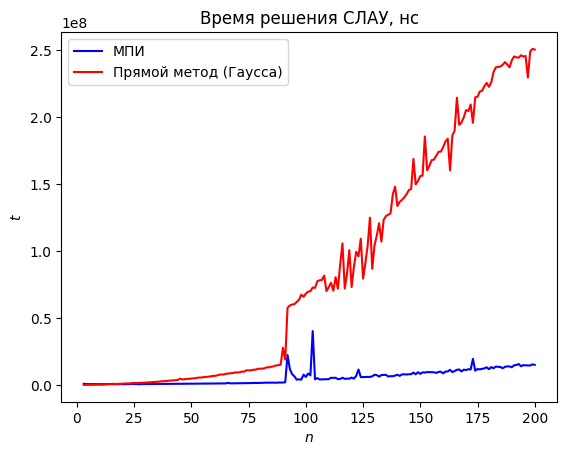

In [ ]:
grid_n = np.arange(3, 201, 1)
graph_compare(grid_n)

При последовательных запусках предыдущей ячейки графики могут несколько видоизменяться. Их "зубчатая" форма и случайное появление пиков (как в синей, так и в красной кривой) связаны в том числе со стохастическим характером процедуры измерения времени. Однако на всех графиках заметно одно и то же поведение времени расчёта по МПИ: при $n<50$ оно близко ко времени расчёта по методу Гаусса, но при дальнейшем увеличении $n$ оказывается заметно меньше.

Если рассмотреть большие $n$ ($200\leq n\leq1000$), то выяснится что продолжительности двух вариантов расчёта имеют один и тот же порядок (около нескольких секунд), хотя решение по МПИ снова строится немного быстрее:

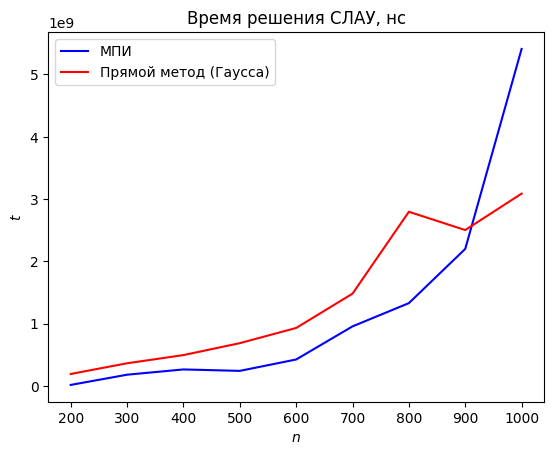

In [ ]:
grid_n = np.arange(200, 1001, 100)
graph_compare(grid_n)

**Упражнение.** В функции ```timer``` замените пользовательскую реализацию метода Гаусса встроенной реализацией (раскомментируйте соответствующую строку). Как при этом выглядят построенные выше графики? Чем это можно объяснить?

В заключение ещё раз отметим, что МПИ является не самым эффективным итерационным методом решения СЛАУ. Существуют и другие, более эффективные методы. Например, можно рассмотреть простейшее обобщение МПИ, заключающееся в использовании не одного итерационного параметра $\tau$, а последовательности из $m$ таких параметров $\tau_k$. В этом случае говорят о $m$**-параметрическом** (или $m$-шаговом) **МПИ**:

$$\textbf{x}^{(k+1)}=(\textbf{E}-\tau_k\textbf{A}) \textbf{x}^{(k)}+\tau_k\textbf{f},\quad k=1,\,2,\,\dots,\, m.$$

После $m$ шагов полученное приближение принимается за нулевое и процесс повторяется до сходимости с требуемой точностью. В весеннем семестре мы обсудим, чем объясняется такое необычное построение метода и как следует выбирать параметры $\tau_k$. Отметим, что в некоторых случаях (например, при решении плохо обусловленных СЛАУ) использование указанной модификации МПИ позволяет существенно ускорить итерации.

С тремя другими итерационными методами решения СЛАУ (более эффективными, чем МПИ) мы познакомимся на следующем семинаре. Повторим, что проведённое нами подробное рассмотрение МПИ носило, скорее, педагогический характер.

# Практические задачи

## Задача A

Написать программу для решения СЛАУ

$$
  \begin{cases}
    2a_1-a_2=\exp\Big[-\big(1-N/2\big)^2\Big],\\[0.2cm]
    -a_{i-1}+2a_i-a_{i+1}=\exp\Big[-\big(i-N/2\big)^2\Big],\quad i=2,\,\dots,\, N-2,\\[0.2cm]
    -a_{N-2}+2a_{N-1}=\exp\Big[-\big(N-1-N/2\big)^2\Big]
  \end{cases}
$$

методом простых итераций с **произвольным** параметром $\tau$. Для случая $N=50$ построить график зависимости количества итераций $s$, необходимого для достижения заданной точности $\varepsilon$, от $\tau$. Определить по графику оптимальное значение итерационного параметра $\tau_\text{opt}$. Сравнить его с теоретическим значением.

Дополнительные вопросы:
1.  Какую дифференциальную задачу аппроксимируют уравнения СЛАУ?
2.  Какой метод решения данной СЛАУ наиболее эффективен? Сравнить сложность эффективного метода и построенного МПИ.

# Литература и другие источники

**Видеозаписи:**

1. Вычислительная математика — лекция 3. Лектор — Е.Н. Аристова. [Ссылка](https://m.youtube.com/watch?v=mMWOaiq-sC0&t=4255s) (YouTube).

2. Вычислительная математика — лекция 4. Лектор — Е.Н. Аристова. [Ссылка](https://m.youtube.com/watch?v=1MzfHvgqb78&t=22s) (YouTube).

3. Вычислительная математика — лекция 5. Лектор — Е.Н. Аристова. [Ссылка](https://m.youtube.com/watch?v=9yDoZU_WkuQ&t=2845s) (YouTube).

4. Вычислительная математика — лекция 5. Лектор — А.В. Чикиткин. [Ссылка](https://m.youtube.com/watch?v=vS_3zWYYFVg) (YouTube).

5. Метод простой итерации для решения СЛАУ — видеоразбор темы. Преподаватель — Н.И. Караваева. [Ссылка](https://vkvideo.ru/video-212608323_456239024) (VK Видео). Анализ сходимости МПИ проводится с помощью разложения невязки по собственным векторам матрицы СЛАУ. На конкретных примерах разбирается ряд выделенных случаев, когда в разложении невязки на нулевой итерации отсутствуют слагаемые, соответствующие различным собственным векторам.

**Рекомендуемая литература (с комментариями):**

В литературе по прикладной линейной алгебре теория итерационных методов решения СЛАУ обычно строится в общем виде — для целого класса итерационных процессов. Соответствующие учебники лучше читать после изучения **нескольких** конкретных примеров итерационных методов, и мы дадим ссылки на эти книги в конце следующего семинара. Пока же ограничимся литературой, в которой МПИ рассматривается независимо от остальных итерационных методов. Таких источников совсем немного:

1.   *В.С. Рябенький. Введение в вычислительную математику.* Компактное и достаточно подробное изложение основных сведений по МПИ можно найти в первом параграфе пятой главы (стр. 105—118). Четвёртый пункт параграфа можно опустить без ущерба для остального материала. Присутствует доказательство критерия сходимости МПИ. Выводится выражение для скорости сходимости через анализ расположения собственных чисел оператора перехода.

2.   *В.И. Косарев. 12 лекций по вычислительной математике.* Итерационные методы решения СЛАУ рассмотрены в третьей лекции (стр. 38—50). Наиболее подробно изучается однопараметрический метод итераций (который мы в нашем изложении называли просто методом простых итераций), но рассмотрены также и другие методы (соответствующие части лекции пока можно пропустить). Интересно дополнение к лекции, в которой очень просто изложена суть $m$-параметрического МПИ.

3.   *А.И. Лобанов, И.Б. Петров. Вычислительная математика: курс лекций.* МПИ посвящёны пункты 2.5.1 и 2.5.2 второй лекции (стр. 54—57). Заслуживает внимания вопрос о роли ошибок округления при вычислении последовательных приближений. Приведена каноническая форма записи двухслойных итерационных процессов (мы скажем о ней на следующем семинаре). Напомним, что помимо указанного учебника существует книга тех же авторов с похожим названием: "Лекции по вычислительной математике" (издание 2006 г.). Лучше пользоваться названной выше книгой (издания 2021 г.). В более новом учебнике устранены замеченные опечатки, а материал отдельных лекций значительно переработан.

Итерационные методы решения спектральных задач излагаются во многих книгах по прикладной линейной алгебре. Мы рекомендуем две:

4. *Д.К. Фаддеев, В.Н. Фаддеева. Вычислительные методы линейной алгебры.* Итерационным методам решения частичной спектральной проблемы посвящена глава V (стр. 328—391). В ней детально разобран степенной метод, а также изложены некоторые другие методы. Вообще говоря, в книге можно найти много материала, относящегося к решению спектральных задач (главы IV, V, VIII, IX, отдельные параграфы глав VI и VII). В ней разбираются и итерационные методы решения СЛАУ, но соответствующую главу (III, стр. 204—256) лучше читать после следующего семинара, поскольку ряд вопросов в ней освещается в контексте сразу нескольких методов.

5. *Дж.Х. Уилкинсон. Алгебраическая проблема собственных значений.* Известная книга признанного специалиста по прикладной линейной алгебре. Её название не очень удачно, поскольку наряду со спектральными задачами в ней разбирается и многое другое (например, довольно подробно рассматриваются методы решения СЛАУ). Впрочем, вопрос о собственных значениях и собственных векторах действительно поставлен во главу угла; это чувствуется на протяжении всей книги. Подробное изложение степенного метода (и других итерационных методов для спектральных задач) можно найти в девятой главе (стр. 493—558).

Дополнительная литература:

6.   *Р.С. Пастушков. Задачи и упражнения по вычислительной математике. V семестр. Решения, указания, ответы.* МПИ посвящены задачи 2.18—2.21 (стр. 12—14). Напомним, что это пособие есть в библиотеке МФТИ. В электронном виде его легче всего скачать с сайта О.А. Пырковой (см. ниже).

7.   *Victor Kozyakin. On accuracy of approximation of the spectral radius by the Gelfand formula.* Статья из журнала "Linear Algebra and its Applications". Мы приводим её в качестве обоснования именного названия "формула Гельфанда", поскольку это название приводится не во всех учебниках. Статья содержит ссылку на оригинальную работу И.М. Гельфанда 1941 г. (написанную на немецком языке). Впрочем, работа Козякина интересна и сама по себе. Скачать текст можно по [ссылке](https://arxiv.org/pdf/0810.2856).

8.   *Е.А. Горин. От спектрального радиуса к основной теореме алгебры.* Очень доступная методическая статья, содержащая основные сведения по элементарному функциональному анализу, сконцентрированные вокруг понятия спектрального радиуса. Подходит для повышения общематематической культуры. [Ссылка](https://www.mathnet.ru/php/archive.phtml?wshow=paper&jrnid=mp&paperid=5&option_lang=rus) на страницу статьи на портале MathNet.

**Сайты и другие электронные ресурсы:**
1. *Guide to Lightning-fast JAX.* Неплохая статья, подходящая для быстрого освоения библиотеки JAX на элементарном уровне. [Ссылка.](https://www.analyticsvidhya.com/blog/2024/10/jax/)

2. Персональный сайт преподавателя МФТИ О.А. Пырковой. Содержит много полезных материалов по различным математическим курсам МФТИ. Страница с материалами осеннего семестра по вычислительной математике: [ссылка](https://www.pyrkovaoa-fizteh.ru/консультация-вычм-5/).

3. Scientific Python Lectures. Очень полезный ресурс, представляющий собой учебник по научному программированию на языке Python. Представлено много различных библиотек. Есть pdf-версия. Все материалы на английском языке. [Ссылка.](https://lectures.scientific-python.org/)

# Контрольные вопросы

1.   Какими недостатками обладают прямые методы решения СЛАУ? Почему итерационные методы представляют интерес?
2. В каких случаях следует предпочитать итерационные методы прямым, а в каких — наоборот?
3.   В чём состоит метод простой итерации решения СЛАУ? Что такое итерационный параметр? оператор перехода? скорость сходимости итерационного процесса?
4.   Сформулируйте достаточное условие сходимости МПИ.
5.   Сформулируйте критерий сходимости МПИ.
6.   Дайте оценку на число итераций, необходимое для получения решения СЛАУ с наперёд заданной точностью $\varepsilon$.
7.   Что такое невязка? По какому закону она меняется? Чем отличаются невязка $\textbf{r}^{(s)}$ и погрешность $\boldsymbol{\Delta}^{(s)}$?
8.   При каких значениях итерационного параметра МПИ для нормальной СЛАУ сходится вне зависимости от начального приближения?
9.   При каком значении итерационного параметра сходимость МПИ для нормальной СЛАУ будет наиболее быстрой?
10.   Влияет ли обусловленность СЛАУ на скорость сходимости МПИ? Если влияет, то как?
11.  Что такое симметризация Гаусса? Для чего она осуществляется? В чём её недостаток?
12.  В чём состоят полная и частичная спектральные проблемы?
13.  Какое собственное значение матрицы называется доминирующим в спектре?
14.  В чём заключается степенной метод поиска доминирующего собственного значения? Каким недостатком он обладает?
15.  Как можно ускорить итерации степенного метода? При каком виде матрицы это удаётся сделать наиболее эффективно?
16.  В каком случае удаётся найти наименьшее собственное значение матрицы с помощью степенного метода? Как это делается?
17.  Что такое спектральный радиус матрицы (оператора)?
18.  Дайте оценку сверху на спектральный радиус произвольной матрицы.
19.  Напишите формулу Гельфанда.